# Hotel Review ABSA
**Aspect-Based Sentiment Analysis** trên đánh giá khách sạn tiếng Việt

| # | Model | Loại | Framework |
|---|-------|------|-----------|
| 1 | Logistic Regression | Baseline | scikit-learn |
| 2 | Random Forest | Baseline | scikit-learn |
| 3 | CNN-LSTM | Deep Learning | PyTorch |
| 4 | PhoBERT | Transformer | HuggingFace |
| 5 | LLaMA-3.2-1B (QLoRA) | LLM | Unsloth |

**Nhãn:** 0 = None, 1 = Negative, 2 = Positive  
**6 Aspects:** Room_Facilities, Service_Staff, Location, Food_Beverage, Price_Value, General



## Section 0 — Cấu hình chung

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, csv, random, time, pickle, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from tqdm.auto import tqdm

PROJECT_DIR  = '/content/drive/MyDrive/ML_ABSA_5T'
DATASET_DIR  = os.path.join(PROJECT_DIR, 'dataset')
MODEL_DIR    = os.path.join(PROJECT_DIR, 'models')
RESULTS_DIR  = os.path.join(PROJECT_DIR, 'results')

TRAIN_CSV = os.path.join(DATASET_DIR, 'train.csv')
VAL_CSV   = os.path.join(DATASET_DIR, 'val.csv')
TEST_CSV  = os.path.join(DATASET_DIR, 'test.csv')

for d in [DATASET_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Aspects
CATEGORIES      = ['Room_Facilities', 'Service_Staff', 'Location',
                   'Food_Beverage', 'Price_Value', 'General']
SENTIMENT_VALS  = ['None', 'Negative', 'Positive']
NUM_CLASSES     = 3
NUM_LABELS      = len(CATEGORIES) * NUM_CLASSES

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print(" Cấu hình xong!")
print(f"   Project : {PROJECT_DIR}")
print(f"   Dataset : {DATASET_DIR}")
print(f"   Models  : {MODEL_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Cấu hình xong!
   Project : /content/drive/MyDrive/ML_ABSA_5T
   Dataset : /content/drive/MyDrive/ML_ABSA_5T/dataset
   Models  : /content/drive/MyDrive/ML_ABSA_5T/models


##  Section 1 — Cài đặt thư viện

In [ ]:
!pip install -q transformers[torch] datasets accelerate underthesea scikit-learn seqeval tqdm
!pip install -q tensorflow

Cai dat xong! Hay RESTART RUNTIME truoc khi tiep tuc.


## Section 2 — Hàm Metrics & Visualization (dùng chung cho tất cả model)

In [ ]:
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

# Per-aspect
def compute_full_metrics(y_true_mat, y_pred_mat, model_name="Model"):

    rows = []
    for i, cat in enumerate(CATEGORIES):
        yt, yp = y_true_mat[:, i], y_pred_mat[:, i]
        rows.append({
            "Aspect"     : cat,
            "Accuracy"   : round(accuracy_score(yt, yp) * 100, 2),
            "Precision"  : round(precision_score(yt, yp, average='macro', zero_division=0) * 100, 2),
            "Recall"     : round(recall_score(yt, yp,    average='macro', zero_division=0) * 100, 2),
            "F1_macro"   : round(f1_score(yt, yp,        average='macro', zero_division=0) * 100, 2),
            "F1_weighted": round(f1_score(yt, yp,        average='weighted', zero_division=0) * 100, 2),
        })
    df = pd.DataFrame(rows)
    avg = df[["Accuracy","Precision","Recall","F1_macro","F1_weighted"]].mean().round(2)
    avg["Aspect"] = "── MACRO AVG ──"
    df = pd.concat([df, avg.to_frame().T], ignore_index=True)
    df.insert(0, "Model", model_name)
    return df


def print_metrics(df, model_name=""):
    print(f"\n{'='*65}")
    print(f"  KẾT QUẢ TEST SET — {model_name}")
    print(f"{'='*65}")
    print(df[["Aspect","Accuracy","Precision","Recall","F1_macro"]].to_string(index=False))


#  Confusion Matrix
def plot_confusion_matrices(y_true_mat, y_pred_mat, model_name="Model", save=True):
    """Vẽ 6 confusion matrix (2×3) cho 6 aspects."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"Confusion Matrix — {model_name} (Test Set)",
                 fontsize=14, fontweight='bold', y=1.01)
    labels = ["None", "Neg", "Pos"]

    for idx, (cat, ax) in enumerate(zip(CATEGORIES, axes.flatten())):
        cm      = confusion_matrix(y_true_mat[:, idx], y_pred_mat[:, idx], labels=[0,1,2])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
        sns.heatmap(cm_norm, annot=False, cmap="Blues",
                    xticklabels=labels, yticklabels=labels,
                    ax=ax, cbar=False, linewidths=0.5, linecolor='lightgrey',
                    vmin=0, vmax=1)
        for r in range(3):
            for c in range(3):
                color = "white" if cm_norm[r,c] > 0.6 else "black"
                ax.text(c+0.5, r+0.5,
                        f"{cm[r,c]}\n({cm_norm[r,c]*100:.0f}%)",
                        ha='center', va='center', fontsize=9,
                        color=color, fontweight='bold')
        f1 = f1_score(y_true_mat[:,idx], y_pred_mat[:,idx], average='macro', zero_division=0)
        ax.set_title(f"{cat}\n(F1={f1*100:.1f}%)", fontsize=10)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    plt.tight_layout()
    if save:
        path = os.path.join(RESULTS_DIR, f"cm_{model_name.lower().replace(' ','_')}.png")
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"Saved → {path}")
    plt.show()


#  Learning Curves
def plot_learning_curves(history, model_name="Model", save=True):
    """
    history: dict với keys:
      train_loss, val_loss, train_f1 (hoặc train_acc), val_f1 (hoặc val_acc)
    """
    epochs = range(1, len(history['train_loss']) + 1)
    has_f1 = 'train_f1' in history

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Learning Curves — {model_name}", fontsize=13, fontweight='bold')

    # Loss
    ax = axes[0]
    ax.plot(epochs, history['train_loss'], 'o-', color='#4C72B0', lw=2, ms=4, label='Train')
    ax.plot(epochs, history['val_loss'],   's--',color='#DD8452', lw=2, ms=4, label='Val')
    best = int(np.argmin(history['val_loss']))
    ax.axvline(best+1, color='#C44E52', ls=':', alpha=0.7, label=f'Best ep={best+1}')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Cross-Entropy Loss"); ax.legend(); ax.grid(alpha=0.3)

    # F1 / Accuracy
    ax2 = axes[1]
    tm = history.get('train_f1', history.get('train_acc', []))
    vm = history.get('val_f1',   history.get('val_acc',   []))
    ylabel = "F1-macro (%)" if has_f1 else "Accuracy (%)"
    ax2.plot(epochs, tm, 'o-',  color='#4C72B0', lw=2, ms=4, label='Train')
    ax2.plot(epochs, vm, 's--', color='#DD8452', lw=2, ms=4, label='Val')
    gap   = (tm[-1] - vm[-1]) if tm and vm else 0
    note  = f"⚠️ Overfit (gap={gap:.1f})" if gap > 10 else f"✅ Ổn định (gap={gap:.1f})"
    ax2.set_xlabel("Epoch"); ax2.set_ylabel(ylabel)
    ax2.set_title(f"{ylabel}\n{note}", fontsize=10)
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save:
        path = os.path.join(RESULTS_DIR, f"lc_{model_name.lower().replace(' ','_')}.png")
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"  💾 Saved → {path}")
    plt.show()


# Error Analysis
def error_analysis(test_df, y_true_mat, y_pred_mat, model_name="Model", n=5):
    """Phân tích và in các trường hợp dự đoán sai điển hình."""
    texts  = test_df['text'].values
    errors = []
    for i, (tr, pr) in enumerate(zip(y_true_mat, y_pred_mat)):
        for j, cat in enumerate(CATEGORIES):
            t, p = int(tr[j]), int(pr[j])
            if t != p:
                if t == 0:   etype = "False Positive (nhận nhầm None)"
                elif p == 0: etype = "False Negative (bỏ sót aspect)"
                else:        etype = "Wrong Sentiment (sai cực tính)"
                errors.append({"text": texts[i][:100]+"...",
                                "aspect": cat, "true": SENTIMENT_VALS[t],
                                "pred": SENTIMENT_VALS[p], "type": etype})
    err_df = pd.DataFrame(errors)
    if err_df.empty:
        print("Không có lỗi!"); return err_df

    total_preds = len(y_true_mat) * len(CATEGORIES)
    print(f"\n{'='*60}")
    print(f"🔍 PHÂN TÍCH LỖI — {model_name}")
    print(f"{'='*60}")
    print(f"Tổng lỗi : {len(err_df):,} / {total_preds:,} ({len(err_df)/total_preds*100:.1f}%)")
    print(f"\nPhân loại:\n{err_df['type'].value_counts().to_string()}")
    print(f"\nTheo aspect:\n{err_df['aspect'].value_counts().to_string()}")
    print(f"\n--- Ví dụ điển hình ---")
    for etype in err_df['type'].unique():
        print(f"\n▸ {etype}:")
        for _, row in err_df[err_df['type']==etype].head(n).iterrows():
            print(f"  [{row['aspect']}] True={row['true']} → Pred={row['pred']}")
            print(f"  {row['text']}")
    return err_df



def save_results_json(metrics_df, model_name, extra=None):
    """Lưu metrics ra file JSON để tổng hợp sau."""
    avg_row = metrics_df[metrics_df['Aspect'] == '── MACRO AVG ──'].iloc[0]
    record  = {
        "model":       model_name,
        "timestamp":   datetime.now().strftime('%Y%m%d_%H%M%S'),
        "avg_accuracy":  float(avg_row['Accuracy']),
        "avg_precision": float(avg_row['Precision']),
        "avg_recall":    float(avg_row['Recall']),
        "avg_f1_macro":  float(avg_row['F1_macro']),
        "per_aspect":  {}
    }
    for _, row in metrics_df[metrics_df['Aspect'] != '── MACRO AVG ──'].iterrows():
        record["per_aspect"][row['Aspect']] = float(row['F1_macro'])
    if extra:
        record.update(extra)
    path = os.path.join(RESULTS_DIR, f"{model_name.lower().replace(' ','_')}_results.json")
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(record, f, ensure_ascii=False, indent=2)
    print(f" Results → {path}")
    return record


print(" Hàm metrics sẵn sàng!")


✅ Hàm metrics sẵn sàng!


---
##  Section 3 — Baseline: Logistic Regression & Random Forest
**Không cần GPU.** TF-IDF + sklearn, train ~2 phút.


⏳ Building TF-IDF...
  Vocab size: 15,000

🚀 Training: Logistic Regression
  ✓ Room_Facilities: F1=77.1%
  ✓ Service_Staff: F1=81.8%
  ✓ Location: F1=83.5%
  ✓ Food_Beverage: F1=86.1%
  ✓ Price_Value: F1=83.2%
  ✓ General: F1=60.0%

  KẾT QUẢ TEST SET — Logistic Regression
         Aspect Accuracy Precision Recall F1_macro
Room_Facilities    76.99     76.88  77.43    77.13
  Service_Staff    86.79     80.78  83.02     81.8
       Location    93.29     85.22   82.2    83.52
  Food_Beverage    93.29     84.84  87.66     86.1
    Price_Value    94.01     80.07   87.3    83.25
        General    66.25     57.58  66.49    59.98
── MACRO AVG ──     85.1     77.56  80.68    78.63
Saved → /content/drive/MyDrive/ML_ABSA_5T/results/cm_logistic_regression.png


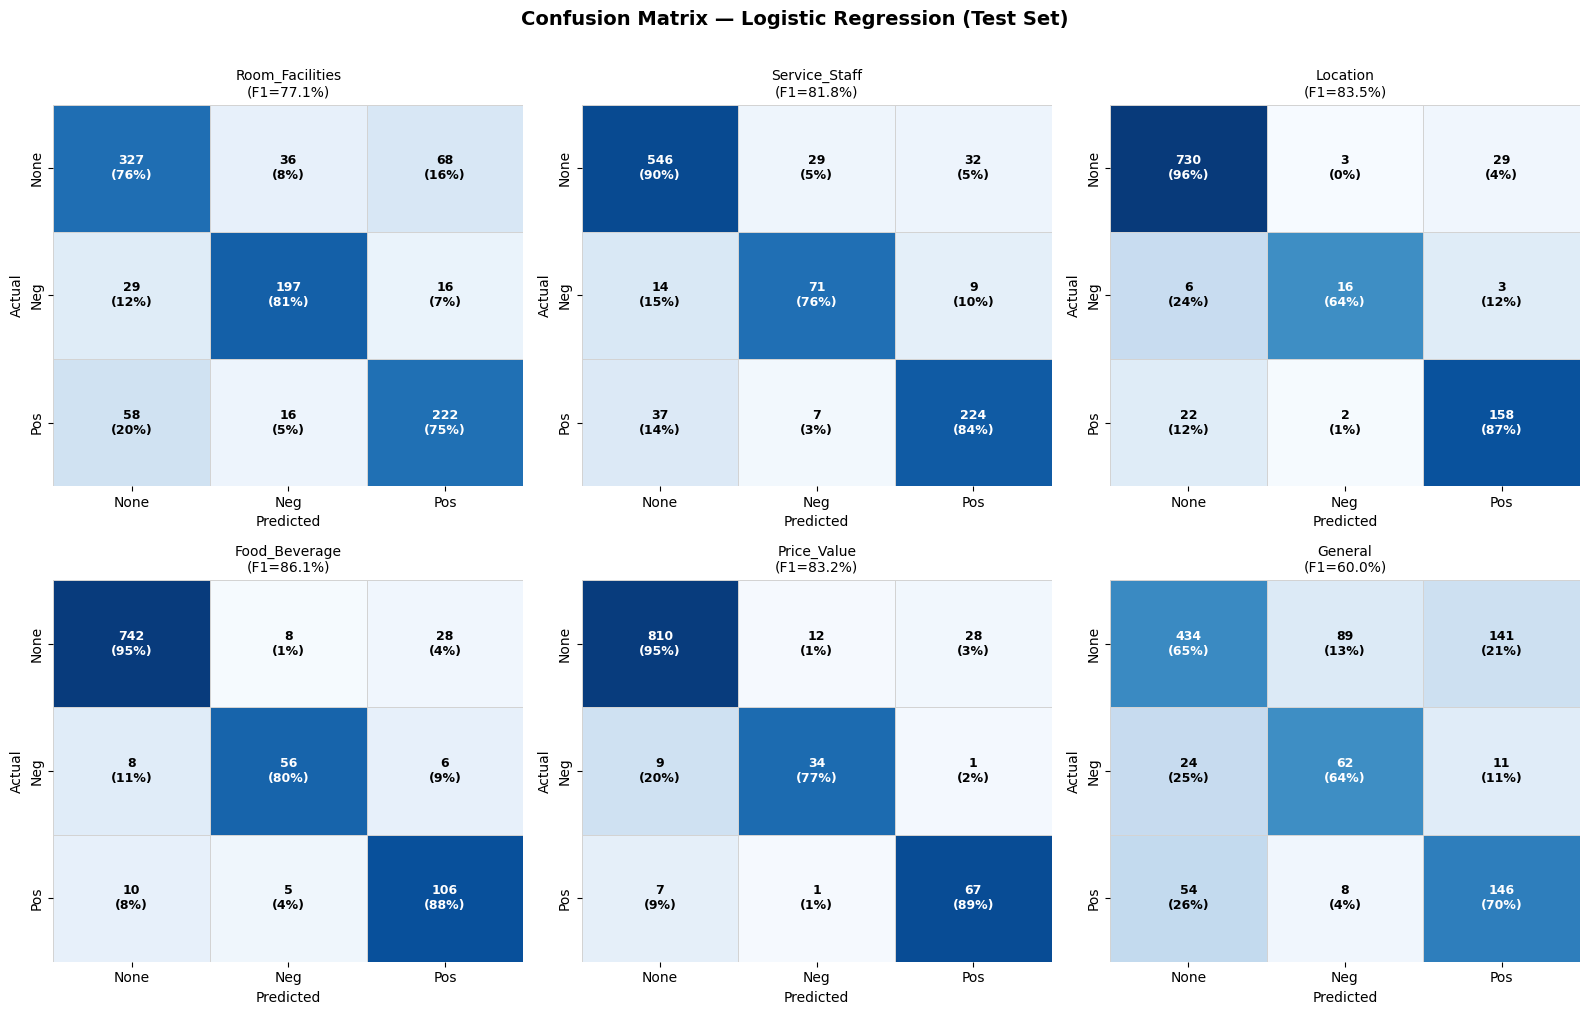


🔍 PHÂN TÍCH LỖI — Logistic Regression
Tổng lỗi : 866 / 5,814 (14.9%)

Phân loại:
type
False Positive (nhận nhầm None)    503
False Negative (bỏ sót aspect)     278
Wrong Sentiment (sai cực tính)      85

Theo aspect:
aspect
General            327
Room_Facilities    223
Service_Staff      128
Location            65
Food_Beverage       65
Price_Value         58

--- Ví dụ điển hình ---

▸ False Positive (nhận nhầm None):
  [Room_Facilities] True=None → Pred=Positive
  tuyệt_vời tòa nhà và phong_cách nội_thất đẹp nhân_viên rất thân_thiện chỉ có hồ bơi tốt hơn nên thay...
  [Location] True=None → Pred=Positive
  phòng giống trên hình rất mới và sạch_sẽ vị_trí cũng rất yên_tĩnh có_điều cách âm chưa được tốt lắm ...
  [General] True=None → Pred=Positive
  phòng giống trên hình rất mới và sạch_sẽ vị_trí cũng rất yên_tĩnh có_điều cách âm chưa được tốt lắm ...
  [General] True=None → Pred=Positive
  nhân_viên khách_sạn cực_kì thân_thiện và phục_vụ rất tốt sẽ quay lại ủng_hộ...
  [Room_Faciliti

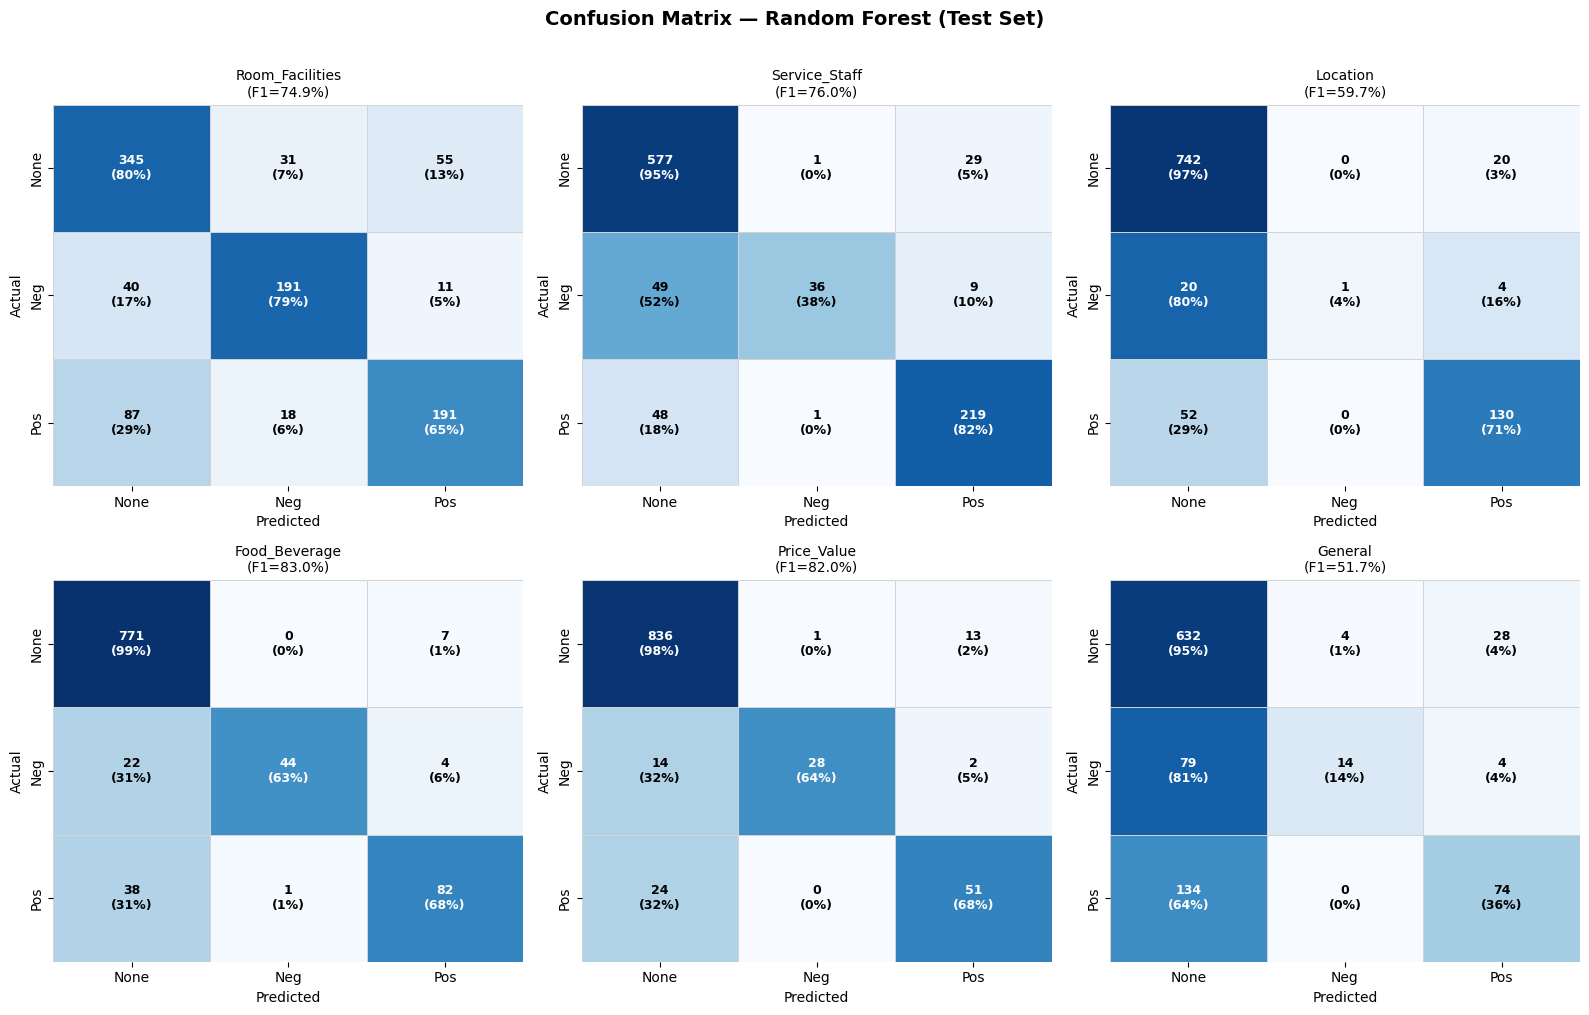


🔍 PHÂN TÍCH LỖI — Random Forest
Tổng lỗi : 850 / 5,814 (14.6%)

Phân loại:
type
False Negative (bỏ sót aspect)     607
False Positive (nhận nhầm None)    189
Wrong Sentiment (sai cực tính)      54

Theo aspect:
aspect
General            249
Room_Facilities    242
Service_Staff      137
Location            96
Food_Beverage       72
Price_Value         54

--- Ví dụ điển hình ---

▸ False Positive (nhận nhầm None):
  [Room_Facilities] True=None → Pred=Positive
  tuyệt_vời tòa nhà và phong_cách nội_thất đẹp nhân_viên rất thân_thiện chỉ có hồ bơi tốt hơn nên thay...
  [General] True=None → Pred=Positive
  nhân_viên khách_sạn cực_kì thân_thiện và phục_vụ rất tốt sẽ quay lại ủng_hộ...
  [Room_Facilities] True=None → Pred=Positive
  rất tốt_tiện_nghi đầy_đủ thoáng mát thoải_mái...
  [Room_Facilities] True=None → Pred=Negative
  checkin 1 phòng hỏng khóa như hình nhân_viên cho đổi sang phòng khác dơ kinh_khủng_sàn nhà bụi bẩn đ...
  [Service_Staff] True=None → Pred=Positive
  checkin 1 phòng 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
import joblib

# Load data
train_df = pd.read_csv(TRAIN_CSV).fillna('')
val_df   = pd.read_csv(VAL_CSV).fillna('')
test_df  = pd.read_csv(TEST_CSV).fillna('')

X_train_raw = train_df['text'].astype(str)
X_val_raw   = val_df['text'].astype(str)
X_test_raw  = test_df['text'].astype(str)

y_train = train_df[CATEGORIES].values.astype(int)
y_val   = val_df[CATEGORIES].values.astype(int)
y_test  = test_df[CATEGORIES].values.astype(int)

# TF-IDF
print(" Building TF-IDF...")
tfidf_vec = TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                             sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_val_tfidf   = tfidf_vec.transform(X_val_raw)
X_test_tfidf  = tfidf_vec.transform(X_test_raw)
print(f"  Vocab size: {len(tfidf_vec.vocabulary_):,}")

# Định nghĩa models
baseline_configs = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced',
        solver='lbfgs', random_state=SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        n_jobs=-1, random_state=SEED),
}

baseline_preds  = {}
baseline_records = {}

for model_name, base_clf in baseline_configs.items():
    print(f"\n{'='*50}")
    print(f"🚀 Training: {model_name}")
    t0 = time.time()

    pred_train = np.zeros_like(y_train)
    pred_val   = np.zeros_like(y_val)
    pred_test  = np.zeros_like(y_test)
    clfs       = {}

    for i, cat in enumerate(CATEGORIES):
        clf = clone(base_clf)
        clf.fit(X_train_tfidf, y_train[:, i])
        clfs[cat]         = clf
        pred_train[:, i]  = clf.predict(X_train_tfidf)
        pred_val[:, i]    = clf.predict(X_val_tfidf)
        pred_test[:, i]   = clf.predict(X_test_tfidf)
        print(f"  ✓ {cat}: F1={f1_score(y_test[:,i], pred_test[:,i], average='macro', zero_division=0)*100:.1f}%")

    elapsed = time.time() - t0

    # Metrics
    metrics_df = compute_full_metrics(y_test, pred_test, model_name)
    print_metrics(metrics_df, model_name)

    # Confusion Matrix
    plot_confusion_matrices(y_test, pred_test, model_name)

    # Error Analysis
    error_analysis(test_df, y_test, pred_test, model_name)

    # Overfitting check
    train_f1 = [f1_score(y_train[:,i], pred_train[:,i], average='macro', zero_division=0)*100 for i in range(6)]
    val_f1   = [f1_score(y_val[:,i],   pred_val[:,i],   average='macro', zero_division=0)*100 for i in range(6)]
    test_f1  = [f1_score(y_test[:,i],  pred_test[:,i],  average='macro', zero_division=0)*100 for i in range(6)]
    print(f"\n  Train avg F1: {np.mean(train_f1):.1f}% | Val: {np.mean(val_f1):.1f}% | Test: {np.mean(test_f1):.1f}%")

    # Lưu checkpoint
    safe_name = model_name.lower().replace(' ','_')
    os.makedirs(os.path.join(MODEL_DIR, safe_name), exist_ok=True)
    joblib.dump(clfs,     os.path.join(MODEL_DIR, safe_name, f'{safe_name}_models.pkl'))
    joblib.dump(tfidf_vec,os.path.join(MODEL_DIR, safe_name, 'tfidf_vectorizer.pkl'))
    np.save(os.path.join(MODEL_DIR, safe_name, 'pred_test.npy'), pred_test)
    print(f"  Checkpoint saved → {MODEL_DIR}/{safe_name}/")

    # Lưu results
    record = save_results_json(metrics_df, model_name,
                                extra={"train_time_s": round(elapsed,1)})
    baseline_preds[model_name]   = pred_test.copy()
    baseline_records[model_name] = record

print("\n Baseline xong!")


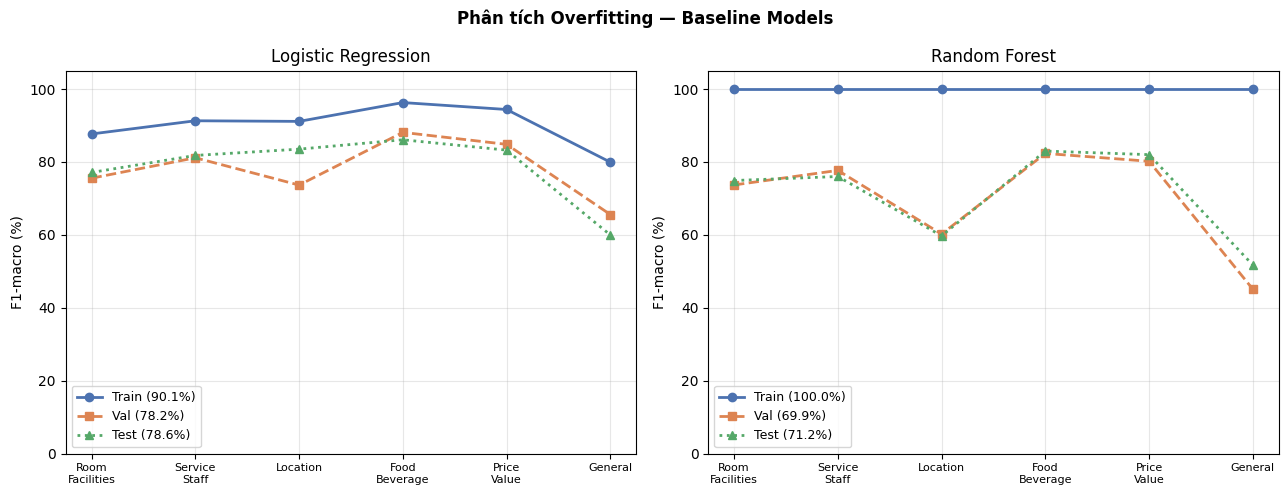

In [ ]:
#  Overfitting visualization — LR vs RF
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Phân tích Overfitting — Baseline Models", fontweight='bold')

for ax, (model_name, base_clf) in zip(axes, baseline_configs.items()):
    safe  = model_name.lower().replace(' ','_')
    clfs_ = joblib.load(os.path.join(MODEL_DIR, safe, f'{safe}_models.pkl'))
    vec_  = joblib.load(os.path.join(MODEL_DIR, safe, 'tfidf_vectorizer.pkl'))

    f1_tr, f1_vl, f1_te = [], [], []
    for i, cat in enumerate(CATEGORIES):
        clf = clfs_[cat]
        f1_tr.append(f1_score(y_train[:,i], clf.predict(X_train_tfidf), average='macro', zero_division=0)*100)
        f1_vl.append(f1_score(y_val[:,i],   clf.predict(X_val_tfidf),   average='macro', zero_division=0)*100)
        f1_te.append(f1_score(y_test[:,i],  clf.predict(X_test_tfidf),  average='macro', zero_division=0)*100)

    x = range(6)
    ax.plot(x, f1_tr, 'o-',  color='#4C72B0', label=f'Train ({np.mean(f1_tr):.1f}%)', lw=2)
    ax.plot(x, f1_vl, 's--', color='#DD8452', label=f'Val ({np.mean(f1_vl):.1f}%)',   lw=2)
    ax.plot(x, f1_te, '^:',  color='#55A868', label=f'Test ({np.mean(f1_te):.1f}%)',  lw=2)
    ax.set_xticks(x); ax.set_xticklabels([c.replace('_','\n') for c in CATEGORIES], fontsize=8)
    ax.set_ylabel('F1-macro (%)'); ax.set_title(model_name)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'overfitting_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Section 4 — CNN-LSTM (Deep Learning)
**Cần GPU.** Kiến trúc: Embedding → Conv1D (local n-gram) → Bi-LSTM (sequential) → FC.  
Output: 12 logits (6 aspects × 2 binary: Neg/Pos). Dùng BCEWithLogitsLoss.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#  Hyperparameters
CNN_CFG = {
    'max_words'  : 15000,
    'max_len'    : 128,
    'embed_dim'  : 128,
    'num_filters': 128,
    'kernel_size': 3,
    'hidden_dim' : 256,
    'dropout'    : 0.3,
    'batch_size' : 64,
    'epochs'     : 15,
    'lr'         : 1e-3,
    'patience'   : 5,   # early stopping
}

LABEL_NAMES = []
for cat in CATEGORIES:
    LABEL_NAMES.extend([f'{cat}_Neg', f'{cat}_Pos'])

# Dataset
class ABSADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def get_binary_labels(df):
    """Chuyển nhãn 0/1/2 → binary (Neg=1/0, Pos=1/0) cho mỗi aspect."""
    cols = []
    for cat in CATEGORIES:
        cols.append((df[cat] == 1).astype(float))  # Negative
        cols.append((df[cat] == 2).astype(float))  # Positive
    return np.stack(cols, axis=1)

def binary_to_class(binary_pred):
    """Chuyển binary (12,) → class (6,): 0=None, 1=Neg, 2=Pos."""
    result = np.zeros((len(binary_pred), 6), dtype=int)
    for i in range(6):
        neg = binary_pred[:, i*2]
        pos = binary_pred[:, i*2+1]
        result[:, i] = np.where(pos > neg, 2, np.where(neg > 0.5, 1, 0))
    return result

# Build tokenizer & data
print(" Xây dựng Keras Tokenizer...")
keras_tok = Tokenizer(num_words=CNN_CFG['max_words'], lower=True)
keras_tok.fit_on_texts(train_df['text'].astype(str))

def encode(df): return pad_sequences(
    keras_tok.texts_to_sequences(df['text'].astype(str)),
    maxlen=CNN_CFG['max_len'])

X_tr = encode(train_df); y_tr = get_binary_labels(train_df)
X_vl = encode(val_df);   y_vl = get_binary_labels(val_df)
X_te = encode(test_df);  y_te_bin = get_binary_labels(test_df)

train_loader = DataLoader(ABSADataset(X_tr, y_tr), batch_size=CNN_CFG['batch_size'], shuffle=True)
val_loader   = DataLoader(ABSADataset(X_vl, y_vl), batch_size=CNN_CFG['batch_size'])
test_loader  = DataLoader(ABSADataset(X_te, y_te_bin), batch_size=CNN_CFG['batch_size'])
print(f"  Train: {len(X_tr)} | Val: {len(X_vl)} | Test: {len(X_te)}")

# Model
class CNN_LSTM_ABSA(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size, hidden_dim, num_labels, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv      = nn.Conv1d(embed_dim, num_filters, kernel_size, padding=kernel_size//2)
        self.lstm      = nn.LSTM(num_filters, hidden_dim, batch_first=True, bidirectional=True)
        self.fc        = nn.Linear(hidden_dim * 2, num_labels)
        self.dropout   = nn.Dropout(dropout)
        self.bn        = nn.BatchNorm1d(num_filters)

    def forward(self, x):
        emb  = self.dropout(self.embedding(x))          # (B, L, E)
        conv = F.relu(self.bn(self.conv(emb.permute(0,2,1))))  # (B, F, L)
        conv = conv.permute(0,2,1)                       # (B, L, F)
        _, (h, _) = self.lstm(conv)
        h = self.dropout(torch.cat((h[-2], h[-1]), dim=1))  # (B, 2H)
        return self.fc(h)                                # (B, 12)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Device: {device}")

vocab_size  = min(len(keras_tok.word_index)+1, CNN_CFG['max_words']+1)
cnn_model   = CNN_LSTM_ABSA(vocab_size, CNN_CFG['embed_dim'], CNN_CFG['num_filters'],
                             CNN_CFG['kernel_size'], CNN_CFG['hidden_dim'],
                             len(LABEL_NAMES), CNN_CFG['dropout']).to(device)
optimizer   = torch.optim.Adam(cnn_model.parameters(), lr=CNN_CFG['lr'])
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion   = nn.BCEWithLogitsLoss()

total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"  Params: {total_params:,}")
print(cnn_model)


⏳ Xây dựng Keras Tokenizer...
  Train: 7752 | Val: 969 | Test: 969

🖥️  Device: cuda
  Params: 1,541,516
CNN_LSTM_ABSA(
  (embedding): Embedding(5432, 128, padding_idx=0)
  (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [ ]:
# Training loop
cnn_history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
best_val_f1 = 0.0
patience_cnt = 0
CKPT_PATH   = os.path.join(MODEL_DIR, 'cnn_lstm', 'cnn_lstm_best.pt')
os.makedirs(os.path.join(MODEL_DIR, 'cnn_lstm'), exist_ok=True)

print(f"🚀 Training CNN-LSTM — {CNN_CFG['epochs']} epochs (patience={CNN_CFG['patience']})\n")

for epoch in range(CNN_CFG['epochs']):
    # Train
    cnn_model.train()
    tr_loss = 0.0
    tr_preds, tr_labels = [], []
    for X_b, y_b in tqdm(train_loader, desc=f"Ep{epoch+1} Train", leave=False):
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = cnn_model(X_b)
        loss = criterion(out, y_b)
        loss.backward(); optimizer.step()
        tr_loss += loss.item()
        probs = torch.sigmoid(out).cpu().detach().numpy()
        tr_preds.extend((probs > 0.5).astype(int))
        tr_labels.extend(y_b.cpu().numpy())

    # Val
    cnn_model.eval()
    vl_loss = 0.0
    vl_preds, vl_labels = [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            out   = cnn_model(X_b.to(device))
            vl_loss += criterion(out, y_b.to(device)).item()
            probs  = torch.sigmoid(out).cpu().numpy()
            vl_preds.extend((probs > 0.5).astype(int))
            vl_labels.extend(y_b.numpy())

    tr_f1 = f1_score(tr_labels, tr_preds, average='macro', zero_division=0) * 100
    vl_f1 = f1_score(vl_labels, vl_preds, average='macro', zero_division=0) * 100
    tr_l  = tr_loss / len(train_loader)
    vl_l  = vl_loss / len(val_loader)

    cnn_history['train_loss'].append(tr_l)
    cnn_history['val_loss'].append(vl_l)
    cnn_history['train_f1'].append(tr_f1)
    cnn_history['val_f1'].append(vl_f1)

    scheduler.step(vl_l)
    print(f"Ep {epoch+1:02d} | Loss: {tr_l:.4f}/{vl_l:.4f} | F1: {tr_f1:.1f}%/{vl_f1:.1f}%", end="")

    # Early stopping
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        patience_cnt = 0
        torch.save(cnn_model.state_dict(), CKPT_PATH)
        print(" | Best saved")
    else:
        patience_cnt += 1
        print(f" (patience {patience_cnt}/{CNN_CFG['patience']})")
        if patience_cnt >= CNN_CFG['patience']:
            print(f"  Early stop tại epoch {epoch+1}")
            break

# Lưu history
with open(os.path.join(MODEL_DIR, 'cnn_lstm', 'history.json'), 'w') as f:
    json.dump(cnn_history, f)
print(f"\n ✅ Training xong! Best Val F1: {best_val_f1:.1f}%")


🚀 Training CNN-LSTM — 15 epochs (patience=5)



Ep1 Train:   0%|          | 0/122 [00:00<?, ?it/s]

Ep 01 | Loss: 0.3816/0.3326 | F1: 4.9%/10.8% ✅ Best saved


Ep2 Train:   0%|          | 0/122 [00:00<?, ?it/s]

Ep 02 | Loss: 0.3184/0.2960 | F1: 16.7%/24.5% ✅ Best saved


...

Ep 13 | Loss: 0.1481/0.1902 | F1: 73.9%/66.6% (patience 1/5)


Ep14 Train:   0%|          | 0/122 [00:00<?, ?it/s]

Ep 14 | Loss: 0.1436/0.1961 | F1: 75.5%/66.4% (patience 2/5)


Ep15 Train:   0%|          | 0/122 [00:00<?, ?it/s]

Ep 15 | Loss: 0.1325/0.1883 | F1: 77.5%/70.9% ✅ Best saved

✅ Training xong! Best Val F1: 70.9%


/tmp/ipykernel_5347/827309703.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5347/827309703.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches='tight')


  💾 Saved → /content/drive/MyDrive/ML_ABSA_5T/results/lc_cnn-lstm.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


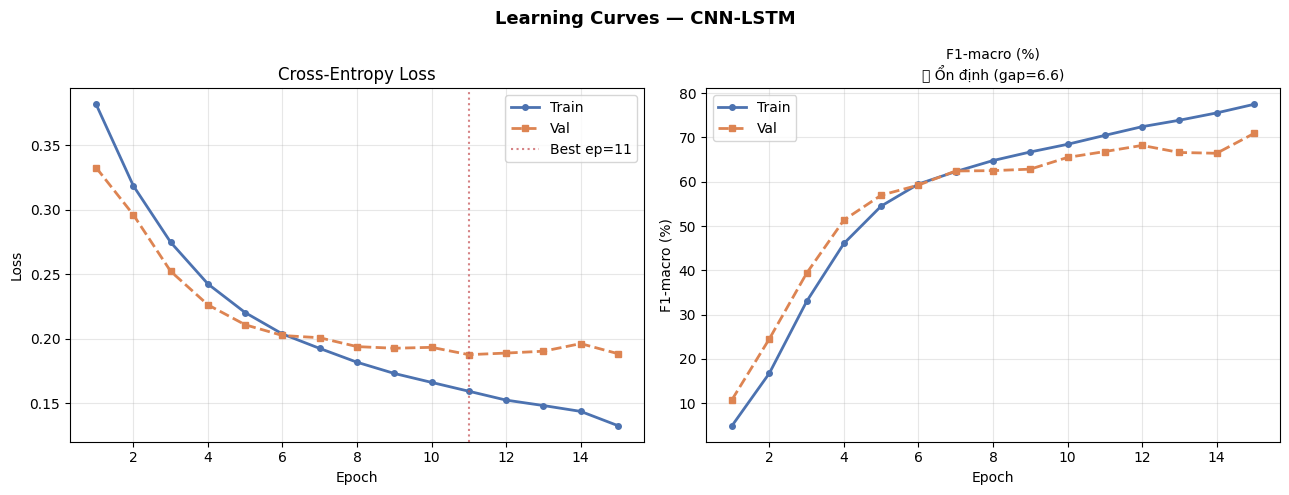


📊 Load best checkpoint & evaluate on Test...


Test:   0%|          | 0/16 [00:00<?, ?it/s]


  KẾT QUẢ TEST SET — CNN-LSTM
         Aspect Accuracy Precision Recall F1_macro
Room_Facilities    75.34      76.0  75.02    75.47
  Service_Staff    87.62     85.19  78.53    81.02
       Location    91.95     92.24  65.32    68.64
  Food_Beverage     93.5     88.49  83.62     85.9
    Price_Value     93.7     78.68  84.75    81.48
        General    75.03     68.61  54.54    58.39
── MACRO AVG ──    86.19     81.54  73.63    75.15
Saved → /content/drive/MyDrive/ML_ABSA_5T/results/cm_cnn-lstm.png


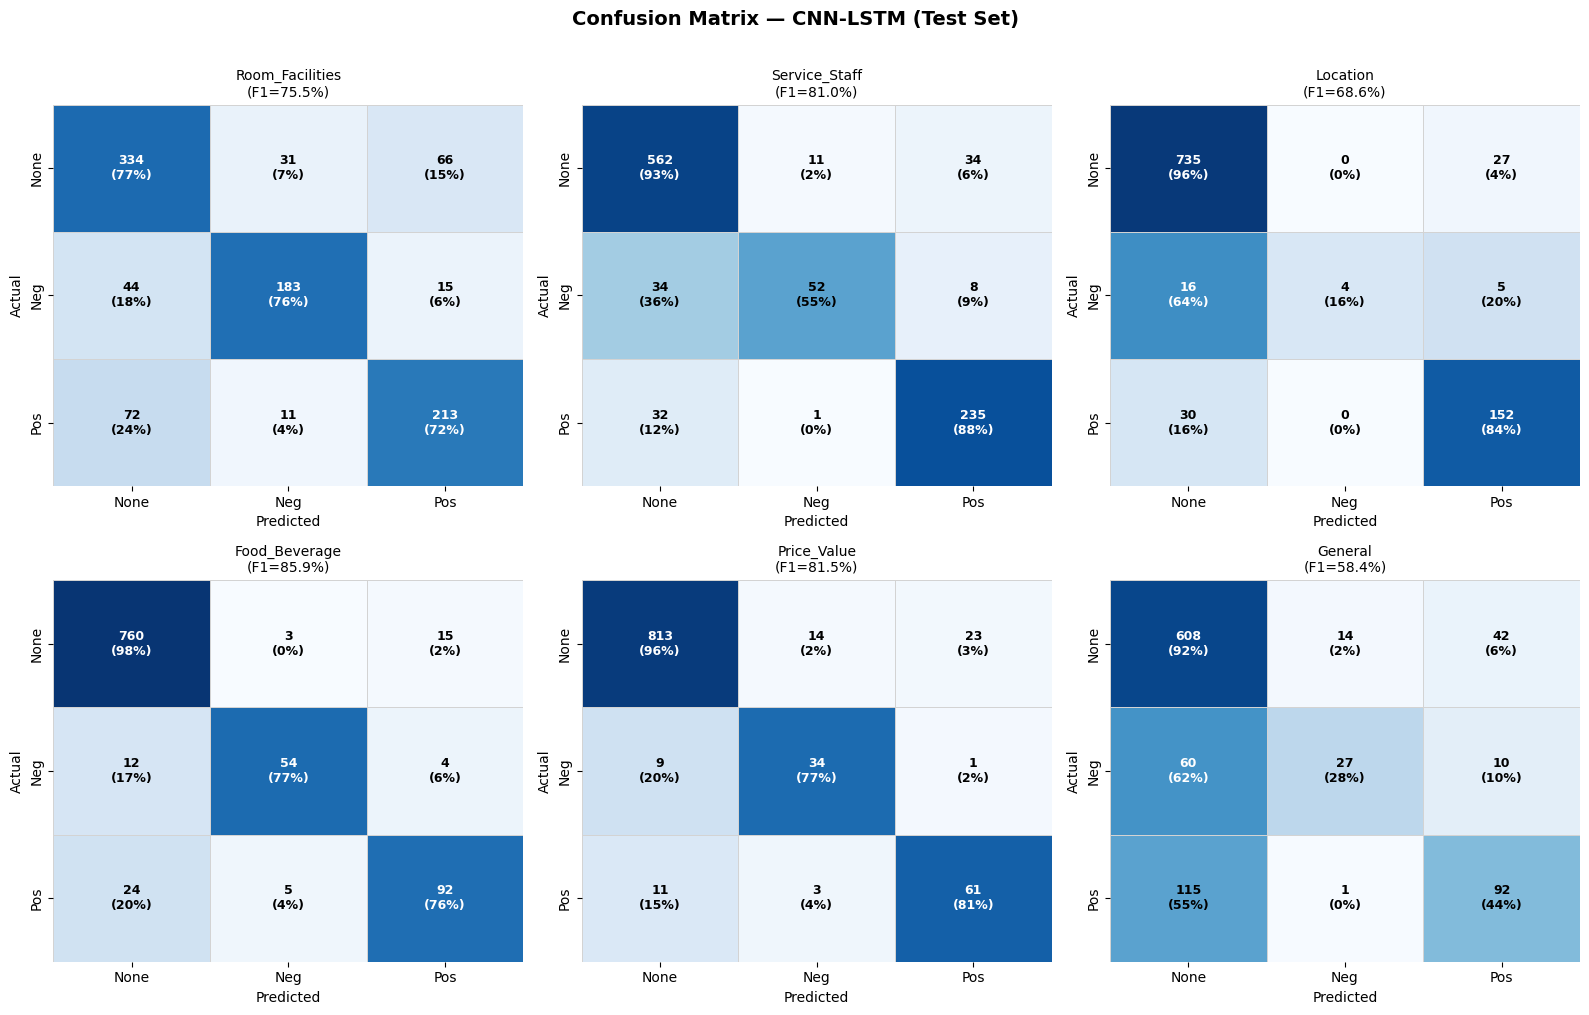


🔍 PHÂN TÍCH LỖI — CNN-LSTM
Tổng lỗi : 803 / 5,814 (13.8%)

Phân loại:
type
False Negative (bỏ sót aspect)     459
False Positive (nhận nhầm None)    280
Wrong Sentiment (sai cực tính)      64

Theo aspect:
aspect
General            242
Room_Facilities    239
Service_Staff      120
Location            78
Food_Beverage       63
Price_Value         61

--- Ví dụ điển hình ---

▸ False Positive (nhận nhầm None):
  [Room_Facilities] True=None → Pred=Positive
  tuyệt_vời tòa nhà và phong_cách nội_thất đẹp nhân_viên rất thân_thiện chỉ có hồ bơi tốt hơn nên thay...
  [Room_Facilities] True=None → Pred=Positive
  rất tốt_tiện_nghi đầy_đủ thoáng mát thoải_mái...
  [Room_Facilities] True=None → Pred=Negative
  checkin 1 phòng hỏng khóa như hình nhân_viên cho đổi sang phòng khác dơ kinh_khủng_sàn nhà bụi bẩn đ...
  [Service_Staff] True=None → Pred=Negative
  checkin 1 phòng hỏng khóa như hình nhân_viên cho đổi sang phòng khác dơ kinh_khủng_sàn nhà bụi bẩn đ...
  [Room_Facilities] True=None → Pred

In [ ]:
# Learning Curves
plot_learning_curves(cnn_history, "CNN-LSTM")

# Test Evaluation
print("\n Load best checkpoint & evaluate on Test...")
cnn_model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
cnn_model.eval()

te_preds_bin, te_labels_bin = [], []
with torch.no_grad():
    for X_b, y_b in tqdm(test_loader, desc="Test"):
        probs = torch.sigmoid(cnn_model(X_b.to(device))).cpu().numpy()
        te_preds_bin.extend((probs > 0.5).astype(int))
        te_labels_bin.extend(y_b.numpy())

# Chuyển binary → class 0/1/2
cnn_pred_test = binary_to_class(np.array(te_preds_bin))

# Metrics
cnn_metrics = compute_full_metrics(y_test, cnn_pred_test, "CNN-LSTM")
print_metrics(cnn_metrics, "CNN-LSTM")
plot_confusion_matrices(y_test, cnn_pred_test, "CNN-LSTM")
error_analysis(test_df, y_test, cnn_pred_test, "CNN-LSTM")

# Lưu
np.save(os.path.join(MODEL_DIR, 'cnn_lstm', 'pred_test.npy'), cnn_pred_test)
# Lưu tokenizer để dùng cho web app
with open(os.path.join(MODEL_DIR, 'cnn_lstm', 'keras_tokenizer.pkl'), 'wb') as f:
    pickle.dump(keras_tok, f)
with open(os.path.join(MODEL_DIR, 'cnn_lstm', 'cnn_cfg.json'), 'w') as f:
    json.dump(CNN_CFG, f)
save_results_json(cnn_metrics, "CNN-LSTM",
                  extra={"epochs_trained": len(cnn_history['train_loss']),
                         "best_val_f1": round(best_val_f1, 2)})
print("\n✅ CNN-LSTM xong! Artifacts đã lưu.")


---
## Section 5 — PhoBERT Fine-Tuning
**Cần GPU.** `vinai/phobert-base` fine-tuned multi-label 18 logits (6×3).  
Loss: BCEWithLogitsLoss. Dùng HuggingFace Trainer với early stopping.


In [ ]:
import gc
from datasets import Dataset as HFDataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from underthesea import word_tokenize

PHOBERT_HUB = 'vinai/phobert-base'
PB_CFG = {
    'max_length' : 256,
    'lr'         : 2e-5,
    'batch_size' : 16,
    'epochs'     : 10,
    'weight_decay': 0.01,
    'patience'   : 3,
}
PB_MODEL_DIR = os.path.join(MODEL_DIR, 'phobert')
os.makedirs(PB_MODEL_DIR, exist_ok=True)

# Data preparation
def prepare_phobert_df(df):
    """Chuyển CSV → HF Dataset với label vector 18 chiều (one-hot per aspect)."""
    rows = []
    for _, row in df.iterrows():
        text_seg = word_tokenize(str(row['text']), format='text')
        label_vec = [0.0] * NUM_LABELS
        for i, cat in enumerate(CATEGORIES):
            val = int(row.get(cat, 0))
            label_vec[i * NUM_CLASSES + val] = 1.0
        rows.append({'text': text_seg, 'labels': label_vec})
    return HFDataset.from_pandas(pd.DataFrame(rows))

print("⏳ Chuẩn bị dataset cho PhoBERT...")
pb_datasets = DatasetDict({
    'train'     : prepare_phobert_df(train_df),
    'validation': prepare_phobert_df(val_df),
    'test'      : prepare_phobert_df(test_df),
})

pb_tokenizer = AutoTokenizer.from_pretrained(PHOBERT_HUB, use_fast=False)

def tokenize_fn(examples):
    return pb_tokenizer(examples['text'], padding='max_length',
                        truncation=True, max_length=PB_CFG['max_length'])

print("⏳ Tokenizing...")
pb_tok = pb_datasets.map(tokenize_fn, batched=True)
print(f"  Train: {len(pb_tok['train'])} | Val: {len(pb_tok['validation'])} | Test: {len(pb_tok['test'])}")

# Metrics callback
pb_history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}

def pb_compute_metrics(eval_pred):
    logits, labels = np.array(eval_pred.predictions), np.array(eval_pred.label_ids)
    true_cls, pred_cls = [], []
    for i in range(len(CATEGORIES)):
        base = i * NUM_CLASSES
        true_cls.append(np.argmax(labels[:, base:base+NUM_CLASSES], axis=1))
        pred_cls.append(np.argmax(logits[:, base:base+NUM_CLASSES], axis=1))
    true_flat = np.concatenate(true_cls)
    pred_flat = np.concatenate(pred_cls)
    return {
        'f1_macro'       : f1_score(true_flat, pred_flat, average='macro', zero_division=0),
        'accuracy'       : accuracy_score(true_flat, pred_flat),
        'precision_macro': precision_score(true_flat, pred_flat, average='macro', zero_division=0),
        'recall_macro'   : recall_score(true_flat, pred_flat, average='macro', zero_division=0),
        **{f'f1_{cat}': f1_score(true_cls[i], pred_cls[i], average='macro', zero_division=0)
           for i, cat in enumerate(CATEGORIES)},
    }

# Training
gc.collect(); torch.cuda.empty_cache()

pb_model = AutoModelForSequenceClassification.from_pretrained(
    PHOBERT_HUB, num_labels=NUM_LABELS,
    problem_type='multi_label_classification')

training_args = TrainingArguments(
    output_dir              = os.path.join(PB_MODEL_DIR, 'checkpoints'),
    eval_strategy           = 'epoch',
    save_strategy           = 'epoch',
    learning_rate           = PB_CFG['lr'],
    per_device_train_batch_size = PB_CFG['batch_size'],
    per_device_eval_batch_size  = PB_CFG['batch_size'],
    num_train_epochs        = PB_CFG['epochs'],
    weight_decay            = PB_CFG['weight_decay'],
    load_best_model_at_end  = True,
    metric_for_best_model   = 'f1_macro',
    greater_is_better       = True,
    save_total_limit        = 1,
    fp16                    = torch.cuda.is_available(),
    logging_steps           = 50,
    report_to               = 'none',
)

trainer = Trainer(
    model           = pb_model,
    args            = training_args,
    train_dataset   = pb_tok['train'],
    eval_dataset    = pb_tok['validation'],
    compute_metrics = pb_compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=PB_CFG['patience'])],
)

print("🚀 BẮT ĐẦU FINE-TUNING PHOBERT...")
trainer.train()


⏳ Chuẩn bị dataset cho PhoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3880, training_loss=0.1932659173134676, metrics={'train_runtime': 1005.4027, 'train_samples_per_second': 77.103, 'train_steps_per_second': 4.824, 'total_flos': 8159719641513984.0, 'train_loss': 0.1932659173134676, 'epoch': 8.0})

/tmp/ipykernel_5347/827309703.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5347/827309703.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches='tight')


  💾 Saved → /content/drive/MyDrive/ML_ABSA_5T/results/lc_phobert.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


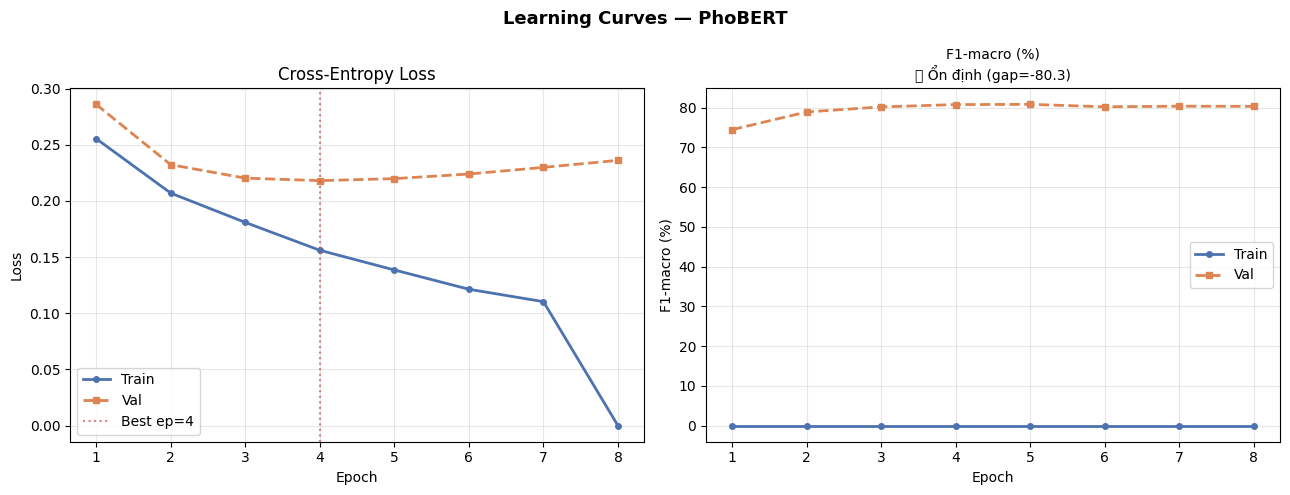


📊 Evaluating on Test Set...



  KẾT QUẢ TEST SET — PhoBERT
         Aspect Accuracy Precision Recall F1_macro
Room_Facilities    79.57     79.65  79.65    79.63
  Service_Staff    88.44     84.19  84.37    84.12
       Location    91.95     91.89   63.9    66.36
  Food_Beverage    94.63     88.81  89.89    89.33
    Price_Value    94.32     82.67   87.1    84.25
        General     77.3     71.86  60.97    64.72
── MACRO AVG ──     87.7     83.18  77.65    78.07
Saved → /content/drive/MyDrive/ML_ABSA_5T/results/cm_phobert.png


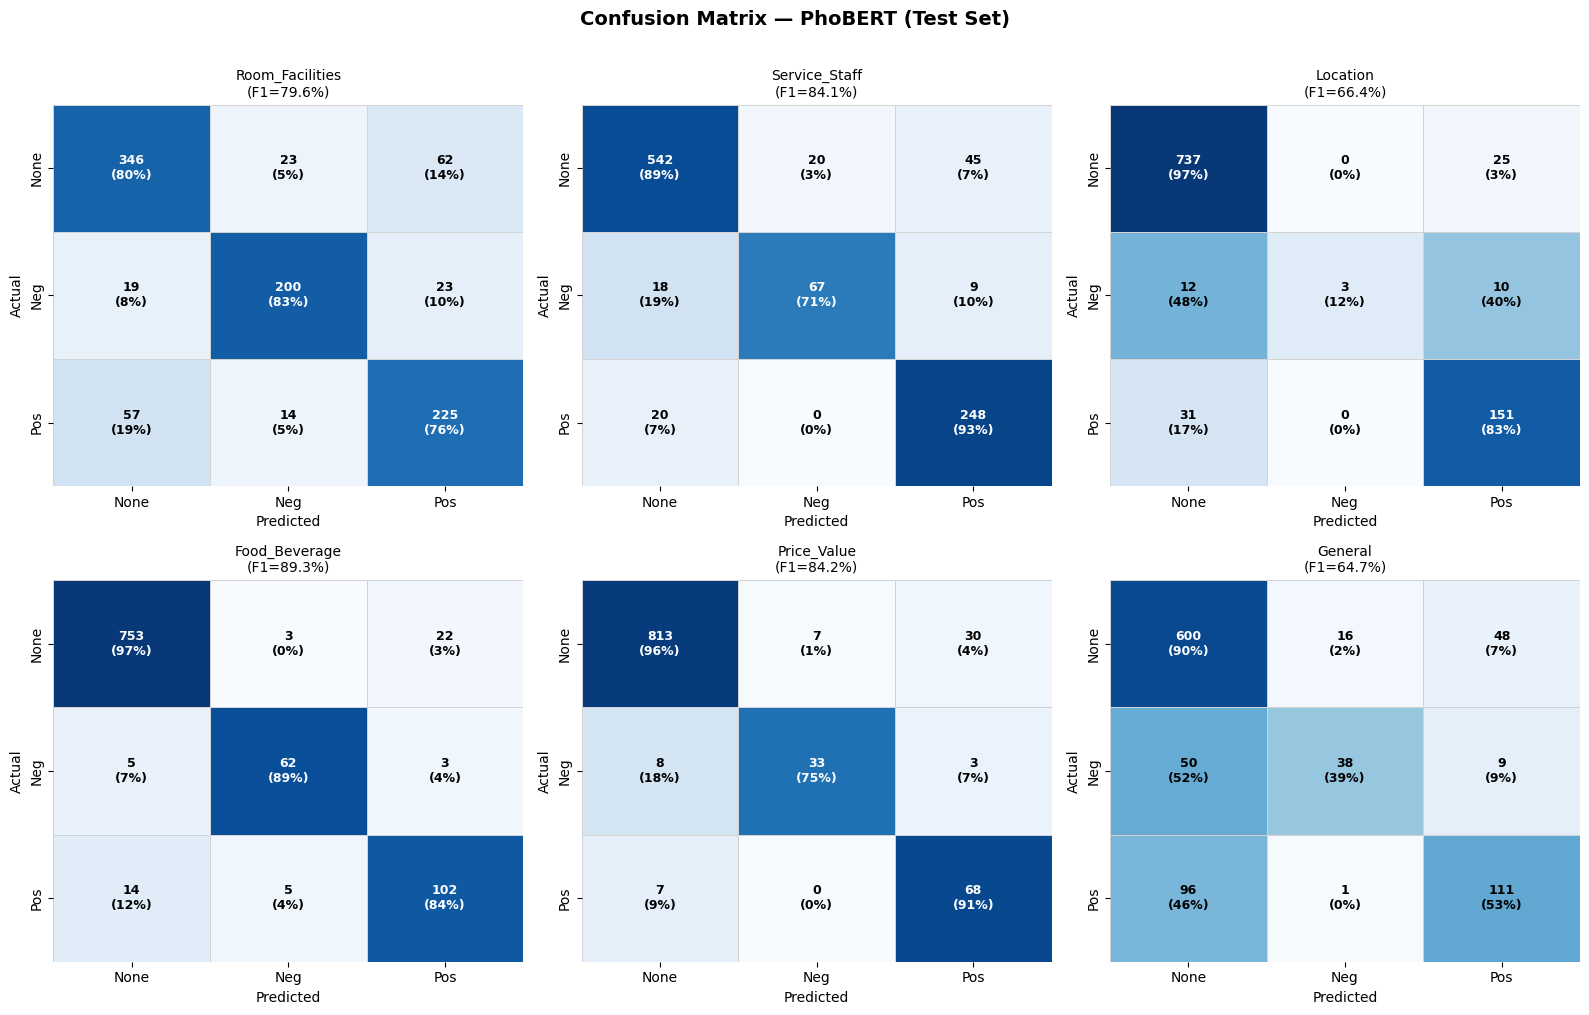


🔍 PHÂN TÍCH LỖI — PhoBERT
Tổng lỗi : 715 / 5,814 (12.3%)

Phân loại:
type
False Negative (bỏ sót aspect)     337
False Positive (nhận nhầm None)    301
Wrong Sentiment (sai cực tính)      77

Theo aspect:
aspect
General            220
Room_Facilities    198
Service_Staff      112
Location            78
Price_Value         55
Food_Beverage       52

--- Ví dụ điển hình ---

▸ False Positive (nhận nhầm None):
  [Room_Facilities] True=None → Pred=Positive
  tuyệt_vời tòa nhà và phong_cách nội_thất đẹp nhân_viên rất thân_thiện chỉ có hồ bơi tốt hơn nên thay...
  [Location] True=None → Pred=Positive
  phòng giống trên hình rất mới và sạch_sẽ vị_trí cũng rất yên_tĩnh có_điều cách âm chưa được tốt lắm ...
  [General] True=None → Pred=Positive
  phòng giống trên hình rất mới và sạch_sẽ vị_trí cũng rất yên_tĩnh có_điều cách âm chưa được tốt lắm ...
  [Location] True=None → Pred=Positive
  tất_cả mọi thứ đều ok không_gian yên_tĩnh không_khí trong_lành 1 sự lựa_chọn tốt cho nghỉ_dưỡng gần ...
  

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 Results → /content/drive/MyDrive/ML_ABSA_5T/results/phobert_results.json

✅ PhoBERT xong! Model → /content/drive/MyDrive/ML_ABSA_5T/models/phobert/final


In [ ]:
# Extract history từ trainer logs
logs = trainer.state.log_history
pb_history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}

# Temporary storage to match train and val losses by epoch
epoch_train_losses = {} # Store a list of train losses for each epoch
epoch_val_losses = {}
epoch_val_f1s = {}

for log in logs:
    epoch_float = log.get('epoch')
    if epoch_float is None:
        continue # Skip logs without an explicit epoch number

    epoch_int = int(epoch_float)

    if 'loss' in log and 'eval_loss' not in log:
        # This is a training loss log
        if epoch_int not in epoch_train_losses:
            epoch_train_losses[epoch_int] = []
        epoch_train_losses[epoch_int].append(log['loss'])
    elif 'eval_loss' in log:
        # This is a validation log
        epoch_val_losses[epoch_int] = log['eval_loss']
        epoch_val_f1s[epoch_int] = log.get('eval_f1_macro', 0) * 100

# Now, iterate through the epochs that had validation results (which defines the "epochs done")
# and collect the corresponding train and validation metrics.
for epoch in sorted(epoch_val_losses.keys()):
    pb_history['val_loss'].append(epoch_val_losses[epoch])
    pb_history['val_f1'].append(epoch_val_f1s[epoch])

    # Get the average training loss for this epoch.
    if epoch in epoch_train_losses and epoch_train_losses[epoch]:
        pb_history['train_loss'].append(np.mean(epoch_train_losses[epoch])) # Using mean for robustness
    else:
        # If a validation log exists for an epoch but no training logs for it,
        # append 0.0 as a placeholder to maintain consistent list lengths for plotting.
        pb_history['train_loss'].append(0.0)

# Ensure train_f1 aligns with the number of epochs where validation was performed
epochs_done = len(pb_history['val_loss'])
pb_history['train_f1'] = [0.0] * epochs_done  # placeholder if train F1 is not logged directly

plot_learning_curves(pb_history, "PhoBERT")

# Test Evaluation
print("\n Evaluating on Test Set...")
test_output = trainer.predict(pb_tok['test'])
test_logits = np.array(test_output.predictions)
test_labels = np.array(test_output.label_ids)

pb_pred_test = np.zeros((len(test_logits), len(CATEGORIES)), dtype=int)
pb_true_test = np.zeros_like(pb_pred_test)
for i in range(len(CATEGORIES)):
    base = i * NUM_CLASSES
    pb_pred_test[:, i] = np.argmax(test_logits[:, base:base+NUM_CLASSES], axis=1)
    pb_true_test[:, i] = np.argmax(test_labels[:, base:base+NUM_CLASSES], axis=1)

pb_metrics = compute_full_metrics(pb_true_test, pb_pred_test, "PhoBERT")
print_metrics(pb_metrics, "PhoBERT")
plot_confusion_matrices(pb_true_test, pb_pred_test, "PhoBERT")
error_analysis(test_df, pb_true_test, pb_pred_test, "PhoBERT")

# Lưu model & tokenizer (cho web app)
FINAL_PB_DIR = os.path.join(PB_MODEL_DIR, 'final')
trainer.save_model(FINAL_PB_DIR)
pb_tokenizer.save_pretrained(FINAL_PB_DIR)
np.save(os.path.join(PB_MODEL_DIR, 'pred_test.npy'), pb_pred_test)
with open(os.path.join(PB_MODEL_DIR, 'history.json'), 'w') as f:
    json.dump(pb_history, f)
save_results_json(pb_metrics, "PhoBERT",
                  extra={"epochs_trained": epochs_done, "base_model": PHOBERT_HUB})
print(f"\n✅ PhoBERT xong! Model → {FINAL_PB_DIR}")

---
## Section 6 — LLaMA-3.2-1B QLoRA Fine-Tuning


In [ ]:
try:
    import unsloth
    print(f'Unsloth OK: {unsloth.__version__}')
except ImportError:
    print('Chua co unsloth - chay cell install o Section 0 truoc')

import torch
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('KHONG CO GPU - can GPU de train LLaMA')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/tmp/ipykernel_5347/2868213878.py:6: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  import unsloth


🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth OK: 2026.4.8
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# unsloth PHAI import truoc tat ca cac thu vien khac
import unsloth  # noqa: F401  (kich hoat cac patch)
from unsloth import FastLanguageModel

# Cac thu vien khac sau unsloth
from datasets import Dataset as HFDataset
from trl import SFTTrainer
from transformers import TrainingArguments

LLAMA_BASE = 'unsloth/Llama-3.2-1B-Instruct'
LLAMA_CFG  = {
    'max_seq_len'    : 1024,
    'load_in_4bit'   : True,
    'lora_r'         : 16,
    'lora_alpha'     : 32,
    'lora_dropout'   : 0.05,
    'target_modules' : ['q_proj','k_proj','v_proj','o_proj',
                        'gate_proj','up_proj','down_proj'],
    'num_epochs'     : 3,
    'batch_size'     : 4,
    'grad_accum'     : 4,
    'lr'             : 2e-4,
    'weight_decay'   : 0.01,
    'warmup_ratio'   : 0.05,
    'seed'           : SEED,
}
LLAMA_MODEL_DIR = os.path.join(MODEL_DIR, 'llama')
os.makedirs(LLAMA_MODEL_DIR, exist_ok=True)

# Prompt templates
TRAIN_TMPL = """Bạn là chuyên gia phân tích cảm xúc đánh giá khách sạn tiếng Việt.
Phân tích đánh giá dưới đây và cho biết sentiment của từng aspect.
Sentiment: None (không đề cập), Negative (tiêu cực), Positive (tích cực).

Đánh giá: {review}

Kết quả (JSON):
{label_json}"""
INFER_TMPL = """Bạn là chuyên gia phân tích cảm xúc đánh giá khách sạn tiếng Việt.
Phân tích đánh giá dưới đây và cho biết sentiment của từng aspect.
Sentiment: None (không đề cập), Negative (tiêu cực), Positive (tích cực).

Đánh giá: {review}

Kết quả (JSON):
"""

def row_to_label_json(row):
    return json.dumps({cat: SENTIMENT_VALS[int(row.get(cat, 0))]
                       for cat in CATEGORIES}, ensure_ascii=False)

def parse_label_json(raw):
    result = {cat: 0 for cat in CATEGORIES}
    try:
        s, e = raw.find('{'), raw.rfind('}')+1
        if s == -1 or e == 0: return result
        parsed = json.loads(raw[s:e])
        for cat in CATEGORIES:
            v = str(parsed.get(cat, '')).strip()
            if v in SENTIMENT_VALS:
                result[cat] = SENTIMENT_VALS.index(v)
            elif 'neg' in v.lower() or 'tiêu' in v.lower(): result[cat] = 1
            elif 'pos' in v.lower() or 'tích' in v.lower(): result[cat] = 2
    except: pass
    return result

# Build dataset
print("Load LLaMA model...")
llama_model, llama_tokenizer = FastLanguageModel.from_pretrained(
    model_name=LLAMA_BASE, max_seq_length=LLAMA_CFG['max_seq_len'],
    load_in_4bit=LLAMA_CFG['load_in_4bit'], dtype=None)

llama_model = FastLanguageModel.get_peft_model(
    llama_model,
    r=LLAMA_CFG['lora_r'], lora_alpha=LLAMA_CFG['lora_alpha'],
    lora_dropout=LLAMA_CFG['lora_dropout'],
    target_modules=LLAMA_CFG['target_modules'],
    bias='none', use_gradient_checkpointing='unsloth',
    random_state=LLAMA_CFG['seed'])

if llama_tokenizer.pad_token is None:
    llama_tokenizer.pad_token = llama_tokenizer.eos_token

EOS = llama_tokenizer.eos_token
def build_llama_dataset(df):
    records = [{'text': TRAIN_TMPL.format(
                    review=str(row['text'])[:1500],
                    label_json=row_to_label_json(row)) + EOS}
               for _, row in df.iterrows()]
    return HFDataset.from_list(records)

llama_train_ds = build_llama_dataset(train_df)
llama_val_ds   = build_llama_dataset(val_df)
print(f"  Train: {len(llama_train_ds)} | Val: {len(llama_val_ds)}")

⏳ Load LLaMA model...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 16 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


  Train: 7752 | Val: 969


In [ ]:
# SFT Training
llama_train_args = TrainingArguments(
    output_dir              = os.path.join(LLAMA_MODEL_DIR, 'checkpoints'),
    num_train_epochs        = LLAMA_CFG['num_epochs'],
    per_device_train_batch_size = LLAMA_CFG['batch_size'],
    gradient_accumulation_steps = LLAMA_CFG['grad_accum'],
    learning_rate           = LLAMA_CFG['lr'],
    weight_decay            = LLAMA_CFG['weight_decay'],
    warmup_ratio            = LLAMA_CFG['warmup_ratio'],
    optim                   = 'adamw_8bit',
    lr_scheduler_type       = 'cosine',
    eval_strategy           = 'epoch',
    save_strategy           = 'epoch',
    load_best_model_at_end  = True,
    save_total_limit        = 1,
    fp16                    = not torch.cuda.is_bf16_supported(),
    bf16                    = torch.cuda.is_bf16_supported(),
    logging_steps           = 20,
    seed                    = LLAMA_CFG['seed'],
    report_to               = 'none',
)

llama_trainer = SFTTrainer(
    model           = llama_model,
    tokenizer       = llama_tokenizer,
    train_dataset   = llama_train_ds,
    eval_dataset    = llama_val_ds,
    dataset_text_field = 'text',
    max_seq_length  = LLAMA_CFG['max_seq_len'],
    args            = llama_train_args,
)

print("🚀 BẮT ĐẦU FINE-TUNING LLAMA...")
llama_trainer.train()
print("✅ Fine-tuning xong!")

# Lưu checkpoint
LLAMA_FINAL = os.path.join(LLAMA_MODEL_DIR, 'final')
llama_model.save_pretrained(LLAMA_FINAL)
llama_tokenizer.save_pretrained(LLAMA_FINAL)
print(f"  💾 Model → {LLAMA_FINAL}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/7752 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/969 [00:00<?, ? examples/s]

🚀 BẮT ĐẦU FINE-TUNING LLAMA...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,752 | Num Epochs = 3 | Total steps = 1,455
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.835937,0.784039
2,0.782646,0.742609
3,0.636084,0.745613


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✅ Fine-tuning xong!


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/ML_ABSA_5T/models/llama/final/tokenizer_config.json.


  💾 Model → /content/drive/MyDrive/ML_ABSA_5T/models/llama/final


Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📊 Evaluating LLaMA trên 969 test samples...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=

  [ 100/969] Accuracy=0.873


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=

...

  [ 800/969] Accuracy=0.882


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=

  [ 900/969] Accuracy=0.887


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=


  KẾT QUẢ TEST SET — LLaMA-3.2-1B
         Aspect Accuracy Precision Recall F1_macro
Room_Facilities    79.98     79.83  81.38    80.31
  Service_Staff     90.3     89.14  83.79    85.88
       Location    93.81     87.89  80.12    83.16
  Food_Beverage    95.15      93.0   89.2    90.98
    Price_Value    94.84     82.84  89.95    85.79
        General    77.09     75.55  57.38    62.28
── MACRO AVG ──    88.53     84.71   80.3     81.4
Saved → /content/drive/MyDrive/ML_ABSA_5T/results/cm_llama-3.2-1b.png


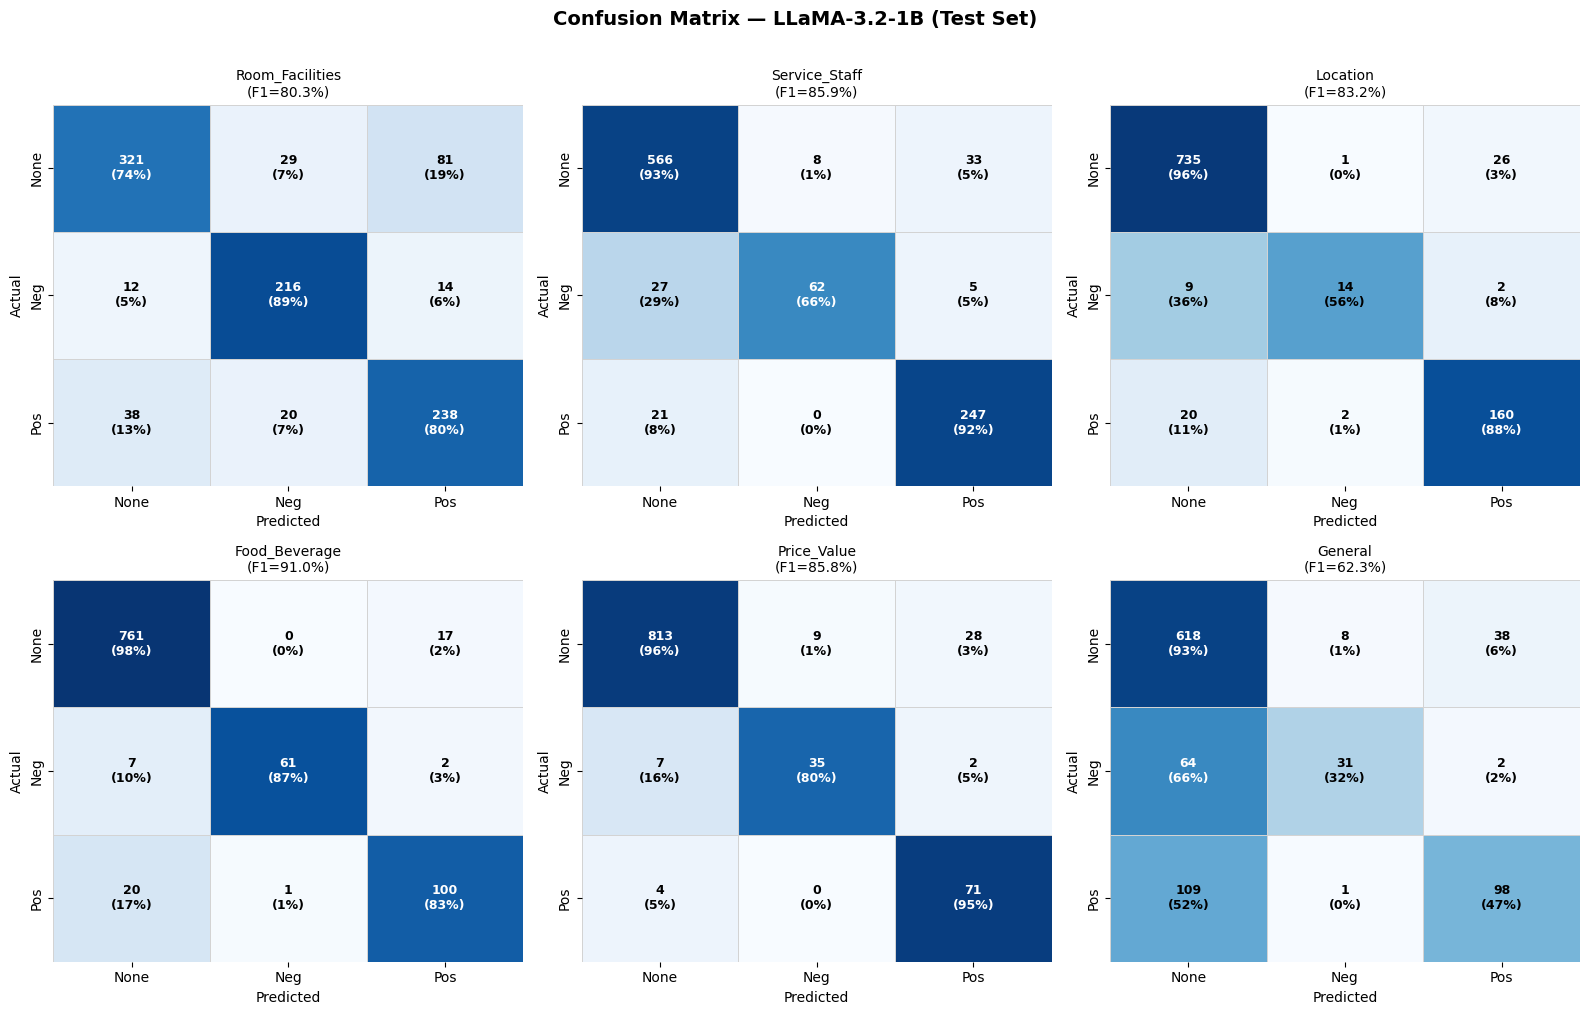


🔍 PHÂN TÍCH LỖI — LLaMA-3.2-1B
Tổng lỗi : 667 / 5,814 (11.5%)

Phân loại:
type
False Negative (bỏ sót aspect)     338
False Positive (nhận nhầm None)    278
Wrong Sentiment (sai cực tính)      51

Theo aspect:
aspect
General            222
Room_Facilities    194
Service_Staff       94
Location            60
Price_Value         50
Food_Beverage       47

--- Ví dụ điển hình ---

▸ False Positive (nhận nhầm None):
  [Room_Facilities] True=None → Pred=Positive
  tuyệt_vời tòa nhà và phong_cách nội_thất đẹp nhân_viên rất thân_thiện chỉ có hồ bơi tốt hơn nên thay...
  [Location] True=None → Pred=Positive
  phòng giống trên hình rất mới và sạch_sẽ vị_trí cũng rất yên_tĩnh có_điều cách âm chưa được tốt lắm ...
  [Room_Facilities] True=None → Pred=Positive
  tất_cả mọi thứ đều ok không_gian yên_tĩnh không_khí trong_lành 1 sự lựa_chọn tốt cho nghỉ_dưỡng gần ...
  [Location] True=None → Pred=Positive
  tất_cả mọi thứ đều ok không_gian yên_tĩnh không_khí trong_lành 1 sự lựa_chọn tốt cho nghỉ_dưỡ

/tmp/ipykernel_5347/827309703.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5347/827309703.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches='tight')


  💾 Saved → /content/drive/MyDrive/ML_ABSA_5T/results/lc_llama-3.2-1b.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


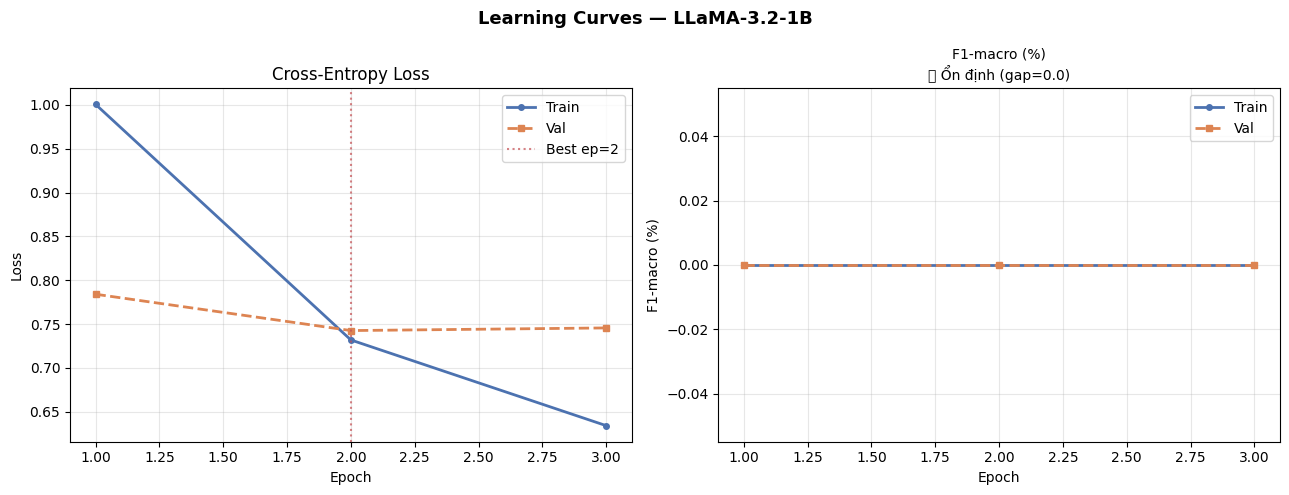

  💾 Results → /content/drive/MyDrive/ML_ABSA_5T/results/llama-3.2-1b_results.json

✅ LLaMA xong!


In [ ]:
# Test Evaluation
FastLanguageModel.for_inference(llama_model)

def llama_predict(text):
    prompt = INFER_TMPL.format(review=text.strip())
    inputs = llama_tokenizer(prompt, return_tensors='pt').to(llama_model.device)
    with torch.no_grad():
        out = llama_model.generate(**inputs, max_new_tokens=128,
                                    do_sample=False, use_cache=True)
    new_tok = out[0][inputs['input_ids'].shape[1]:]
    raw = llama_tokenizer.decode(new_tok, skip_special_tokens=True).strip()
    return parse_label_json(raw)

print(f"Evaluating LLaMA trên {len(test_df)} test samples...")
llama_pred_test = np.zeros((len(test_df), len(CATEGORIES)), dtype=int)
llama_history   = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}

for i, (_, row) in enumerate(test_df.iterrows()):
    pred_dict = llama_predict(str(row['text']))
    for j, cat in enumerate(CATEGORIES):
        llama_pred_test[i, j] = pred_dict[cat]
    if (i+1) % 100 == 0:
        acc = accuracy_score(y_test[:i+1].flatten(), llama_pred_test[:i+1].flatten())
        print(f"  [{i+1:4d}/{len(test_df)}] Accuracy={acc:.3f}")

llama_metrics = compute_full_metrics(y_test, llama_pred_test, "LLaMA-3.2-1B")
print_metrics(llama_metrics, "LLaMA-3.2-1B")
plot_confusion_matrices(y_test, llama_pred_test, "LLaMA-3.2-1B")
error_analysis(test_df, y_test, llama_pred_test, "LLaMA-3.2-1B")

# Lưu history từ trainer logs
train_loss_steps = []
val_loss_epochs  = []

for log in llama_trainer.state.log_history:
    if 'loss' in log and 'eval_loss' not in log:
        train_loss_steps.append(log['loss'])
    if 'eval_loss' in log:
        val_loss_epochs.append(log['eval_loss'])

n_epochs = len(val_loss_epochs)

if train_loss_steps and n_epochs > 0:
    steps_per_epoch = len(train_loss_steps) // n_epochs
    train_loss_per_epoch = []
    for ep in range(n_epochs):
        start = ep * steps_per_epoch
        end   = start + steps_per_epoch if ep < n_epochs - 1 else len(train_loss_steps)
        train_loss_per_epoch.append(round(sum(train_loss_steps[start:end]) / max(1, end - start), 4))
else:
    train_loss_per_epoch = val_loss_epochs

llama_history = {
    'train_loss': train_loss_per_epoch,
    'val_loss':   val_loss_epochs,
    'train_f1':   [0.0] * n_epochs,
    'val_f1':     [0.0] * n_epochs,
}

print(f"History: {n_epochs} epochs | train: {len(train_loss_per_epoch)} | val: {len(val_loss_epochs)}")
plot_learning_curves(llama_history, "LLaMA-3.2-1B")

np.save(os.path.join(LLAMA_MODEL_DIR, 'pred_test.npy'), llama_pred_test)
with open(os.path.join(LLAMA_MODEL_DIR, 'history.json'), 'w') as f:
    json.dump(llama_history, f)
save_results_json(llama_metrics, "LLaMA-3.2-1B",
                  extra={"base_model": LLAMA_BASE, "lora_r": LLAMA_CFG['lora_r']})
print("\n✅ LLaMA xong!")


---
## Section 7 — Tổng hợp Kết quả & So sánh (Chương 4 Báo cáo)
Chạy section này **sau khi đã train xong tất cả 5 models**.


In [ ]:
# Load tất cả predictions
all_preds = {}

# Baseline
for name in ['logistic_regression', 'random_forest']:
    path = os.path.join(MODEL_DIR, name, 'pred_test.npy')
    if os.path.exists(path):
        all_preds[name.replace('_',' ').title()] = np.load(path)

# CNN-LSTM
path = os.path.join(MODEL_DIR, 'cnn_lstm', 'pred_test.npy')
if os.path.exists(path):
    all_preds['CNN-LSTM'] = np.load(path)

# PhoBERT
path = os.path.join(MODEL_DIR, 'phobert', 'pred_test.npy')
if os.path.exists(path):
    all_preds['PhoBERT'] = np.load(path)

# LLaMA
path = os.path.join(MODEL_DIR, 'llama', 'pred_test.npy')
if os.path.exists(path):
    all_preds['LLaMA-3.2-1B'] = np.load(path)

print(f"✅ Loaded {len(all_preds)} models: {list(all_preds.keys())}")


✅ Loaded 5 models: ['Logistic Regression', 'Random Forest', 'CNN-LSTM', 'PhoBERT', 'LLaMA-3.2-1B']


In [ ]:
# ── Bảng so sánh tổng hợp ────────────────────────────────────────
comparison_rows = []
for model_name, pred in all_preds.items():
    # Load results json nếu có
    safe = model_name.lower().replace(' ','_').replace('-','_').replace('.','_')
    rpath = os.path.join(RESULTS_DIR, f'{safe}_results.json')
    extra_info = {}
    if os.path.exists(rpath):
        with open(rpath) as f:
            extra_info = json.load(f)

    df_m = compute_full_metrics(y_test, pred, model_name)
    avg  = df_m[df_m['Aspect'] == '── MACRO AVG ──'].iloc[0]
    comparison_rows.append({
        'Model'        : model_name,
        'Accuracy (%)'  : avg['Accuracy'],
        'Precision (%)' : avg['Precision'],
        'Recall (%)'    : avg['Recall'],
        'F1-macro (%)'  : avg['F1_macro'],
        'Train Time'    : extra_info.get('train_time_s', '—'),
    })

comp_df = pd.DataFrame(comparison_rows).sort_values('F1-macro (%)', ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("  BẢNG SO SÁNH HIỆU NĂNG — TEST SET")
print("="*70)
print(comp_df.to_string(index=False))
print("="*70)

# Lưu bảng ra CSV
comp_df.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'), index=False)



  📊 BẢNG SO SÁNH HIỆU NĂNG — TEST SET
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-macro (%) Train Time
       LLaMA-3.2-1B         88.53          84.71       80.30         81.40          —
Logistic Regression         85.10          77.56       80.68         78.63       19.9
            PhoBERT         87.70          83.18       77.65         78.07          —
           CNN-LSTM         86.19          81.54       73.63         75.15          —
      Random Forest         85.38          85.49       67.57         71.24      148.0


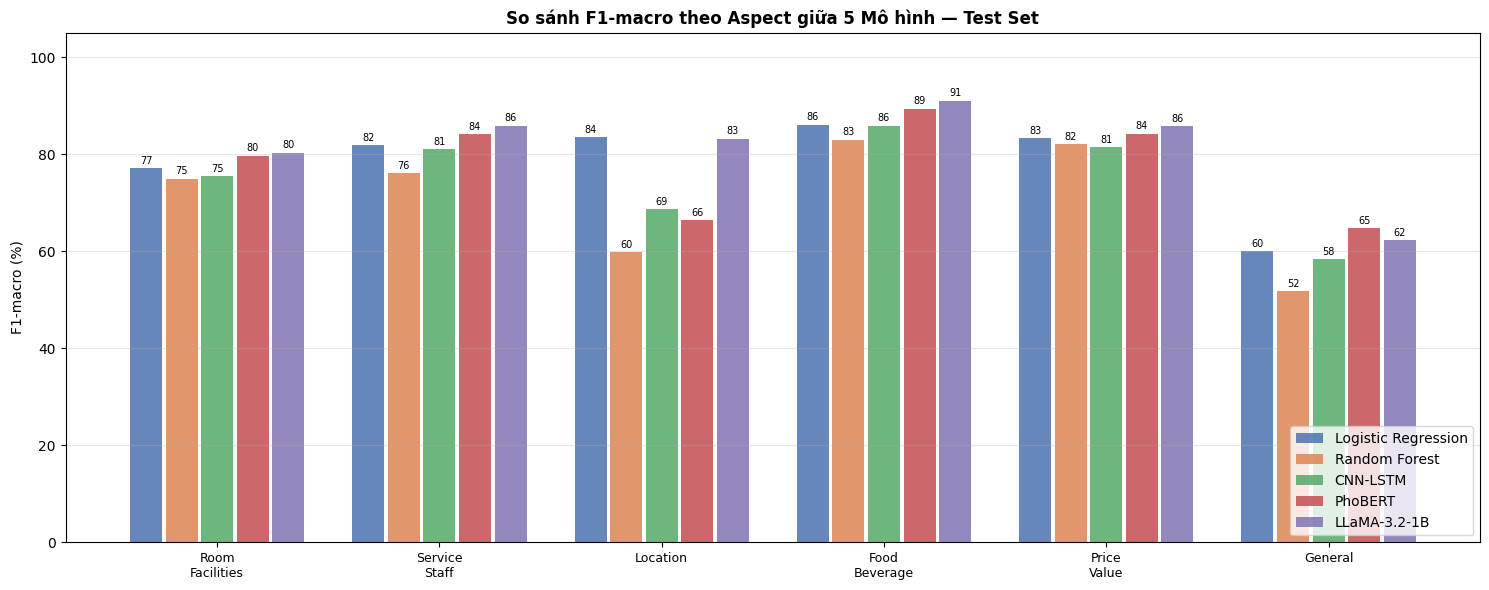

In [ ]:
#  Bar chart F1-macro per aspect
n_models = len(all_preds)
x = np.arange(len(CATEGORIES))
width = 0.8 / n_models
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (model_name, pred) in enumerate(all_preds.items()):
    f1s = [f1_score(y_test[:,j], pred[:,j], average='macro', zero_division=0)*100
           for j in range(6)]
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, f1s, width*0.9, label=model_name,
                  color=colors[i % len(colors)], alpha=0.85)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val:.0f}", ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_','\n') for c in CATEGORIES], fontsize=9)
ax.set_ylabel('F1-macro (%)'); ax.set_ylim(0, 105)
ax.set_title('So sánh F1-macro theo Aspect giữa 5 Mô hình — Test Set',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'f1_comparison_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()



📈 CNN LSTM


/tmp/ipykernel_5347/827309703.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5347/827309703.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches='tight')


  💾 Saved → /content/drive/MyDrive/ML_ABSA_5T/results/lc_cnn_lstm.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


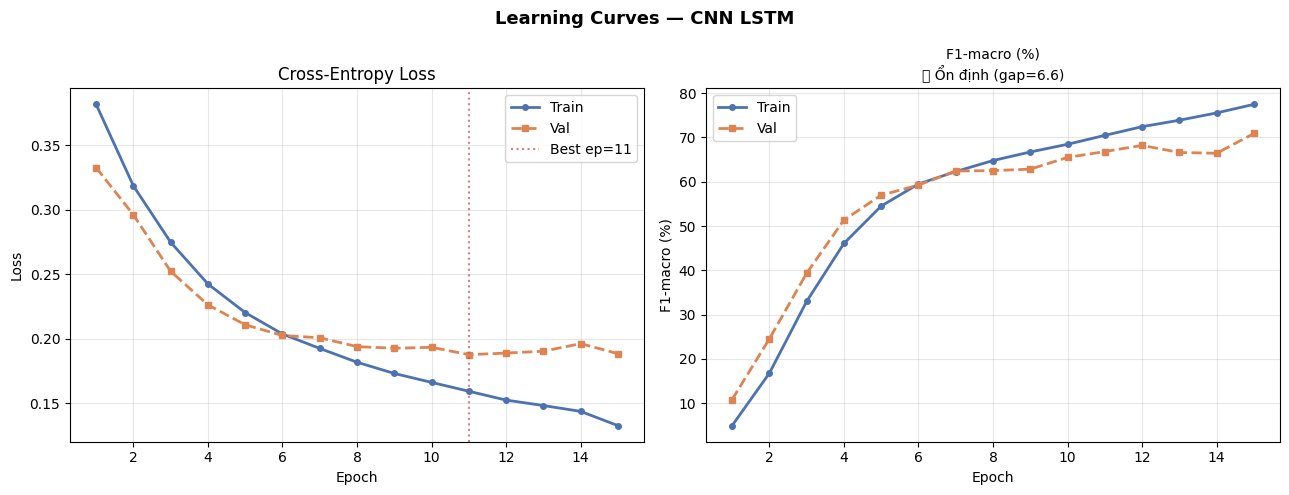


📈 PHOBERT
  💾 Saved → /content/drive/MyDrive/ML_ABSA_5T/results/lc_phobert.png


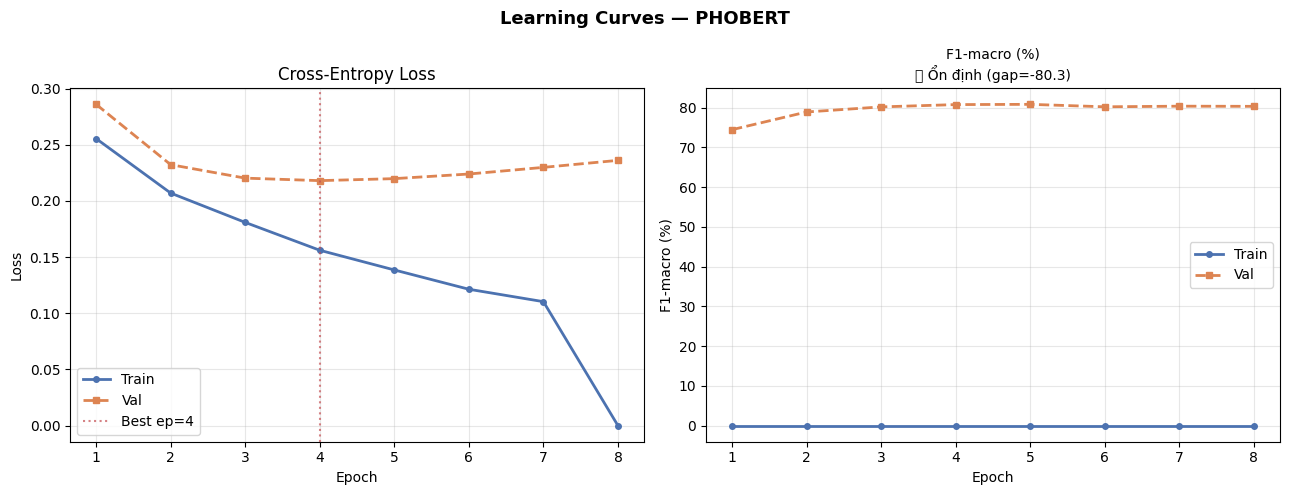


📈 LLAMA
  💾 Saved → /content/drive/MyDrive/ML_ABSA_5T/results/lc_llama.png


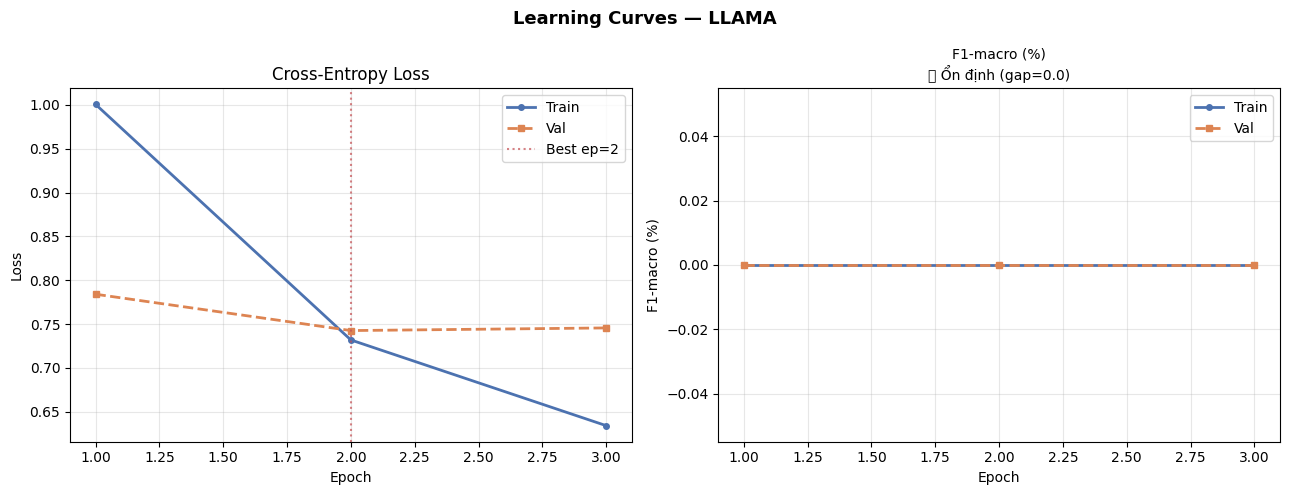

In [ ]:
# ── Learning Curves tất cả DL models ─────────────────────────────
import glob
for hist_file in glob.glob(os.path.join(MODEL_DIR, '*/history.json')):
    model_name = os.path.basename(os.path.dirname(hist_file)).replace('_',' ').upper()
    with open(hist_file) as f:
        hist = json.load(f)
    if hist.get('train_loss'):
        print(f"\n📈 {model_name}")
        plot_learning_curves(hist, model_name)


In [ ]:
# Error Analysis — best model
if 'PhoBERT' in all_preds:
    err_df = error_analysis(test_df, y_test, all_preds['PhoBERT'], 'PhoBERT (Best Model)', n=5)
    err_df.to_csv(os.path.join(RESULTS_DIR, 'error_analysis_phobert.csv'),
                  index=False, encoding='utf-8-sig')

print("\n✅ Section 7 xong! Tất cả outputs đã lưu vào:", RESULTS_DIR)



🔍 PHÂN TÍCH LỖI — PhoBERT (Best Model)
Tổng lỗi : 715 / 5,814 (12.3%)

Phân loại:
type
False Negative (bỏ sót aspect)     337
False Positive (nhận nhầm None)    301
Wrong Sentiment (sai cực tính)      77

Theo aspect:
aspect
General            220
Room_Facilities    198
Service_Staff      112
Location            78
Price_Value         55
Food_Beverage       52

--- Ví dụ điển hình ---

▸ False Positive (nhận nhầm None):
  [Room_Facilities] True=None → Pred=Positive
  tuyệt_vời tòa nhà và phong_cách nội_thất đẹp nhân_viên rất thân_thiện chỉ có hồ bơi tốt hơn nên thay...
  [Location] True=None → Pred=Positive
  phòng giống trên hình rất mới và sạch_sẽ vị_trí cũng rất yên_tĩnh có_điều cách âm chưa được tốt lắm ...
  [General] True=None → Pred=Positive
  phòng giống trên hình rất mới và sạch_sẽ vị_trí cũng rất yên_tĩnh có_điều cách âm chưa được tốt lắm ...
  [Location] True=None → Pred=Positive
  tất_cả mọi thứ đều ok không_gian yên_tĩnh không_khí trong_lành 1 sự lựa_chọn tốt cho nghỉ_dưỡ

---
## Section 8 — Tóm tắt Artifacts đã lưu (cho Deployment)

| Model | File | Dùng cho |
|-------|------|---------|
| LR / RF | `models/logistic_regression/logistic_regression_models.pkl` | Web app inference |
| LR / RF | `models/logistic_regression/tfidf_vectorizer.pkl` | Tokenizer |
| CNN-LSTM | `models/cnn_lstm/cnn_lstm_best.pt` | Model weights |
| CNN-LSTM | `models/cnn_lstm/keras_tokenizer.pkl` | Tokenizer |
| CNN-LSTM | `models/cnn_lstm/cnn_cfg.json` | Config |
| PhoBERT | `models/phobert/final/` | HF model + tokenizer |
| LLaMA | `models/llama/final/` | LoRA adapter + tokenizer |


In [ ]:
# In tổng kết toàn bộ artifacts
print("="*60)
print(" ARTIFACTS ĐÃ LƯU:")
print("="*60)
for root, dirs, files in os.walk(MODEL_DIR):
    level = root.replace(MODEL_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for f in files:
        fsize = os.path.getsize(os.path.join(root, f))
        unit  = 'KB' if fsize < 1e6 else 'MB'
        size  = fsize/1e3 if fsize < 1e6 else fsize/1e6
        print(f'{subindent}{f}  ({size:.1f} {unit})')


📦 ARTIFACTS ĐÃ LƯU:
models/
  vocab.pkl  (158.9 KB)
  lstm_absa_model.pt  (15.4 MB)
  cnn_lstm_absa_model.pt  (3.9 MB)
  cnn_lstm_tokenizer.pkl  (204.7 KB)
  cnn_lstm_labels.pkl  (0.2 KB)
  baseline_tfidf_vectorizer.joblib  (340.6 KB)
  baseline_logistic_regression.joblib  (1.2 MB)
  baseline_random_forest.joblib  (271.7 MB)
  eda_charts/
    5_baseline_optimized.png  (102.7 KB)
  models_llama/
    llama-3.2-1b_checkpoints/
      README.md  (1.5 KB)
      checkpoint-970/
        README.md  (5.3 KB)
        adapter_model.safetensors  (45.1 MB)
        adapter_config.json  (1.2 KB)
        chat_template.jinja  (3.8 KB)
        tokenizer_config.json  (0.4 KB)
        tokenizer.json  (17.2 MB)
        training_args.bin  (5.6 KB)
        optimizer.pt  (23.2 MB)
        scheduler.pt  (1.5 KB)
        scaler.pt  (1.4 KB)
        rng_state.pth  (14.6 KB)
        trainer_state.json  (9.7 KB)
      checkpoint-1455/
        README.md  (5.3 KB)
        adapter_model.safetensors  (45.1 MB)
        